# Note:
- The 3-year survival binary classification for candidate and donor with scaled features, excluding any Max Gini Impurity < 5% on every feature after encoding.
- Using bayesian optimazation with custom scoring function

## Import Libraries

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 
from sklearn.preprocessing import OrdinalEncoder

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv
import UserMetricsFunctions as umf
import UserFeatureSelection as ufs
import HyperParameters as parms

# set seaborn theme
sns.set_theme()

# initializing variables
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


## Import Dataset

In [2]:
# import data
df = pd.read_pickle("../Data/6Clean_ML_Heart_Orig.pkl")
df_can = pd.read_pickle("../Data/6Clean_ML_CAN_Orig.pkl")
df_don = pd.read_pickle("../Data/6Clean_ML_DON_Orig.pkl")
df_both = pd.read_pickle("../Data/6Clean_ML_BOTH_Orig.pkl")
df_ordinal = pd.read_pickle("../Data/6Clean_ML_ordinal_Orig.pkl")
df_nominal = pd.read_pickle("../Data/6Clean_ML_nominal_Orig.pkl")
df_numeric = pd.read_pickle("../Data/6Clean_ML_numeric_Orig.pkl")
df_label = pd.read_pickle("../Data/6Clean_ML_label_Orig.pkl")
# print shape
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Numeric Features: {df_numeric.shape[0]:,}")
print(f"Label Features: {df_label.shape[0]:,}")

Heart Dataset Rows: 27,494 & Columns: 99
Candidate Features: 32
Donor Features: 42
Both Features: 23
Ordinal Features: 33
Nominal Features: 47
Numeric Features: 18
Label Features: 2


### Sanity Check

In [3]:
# combine two lists
allCat = df_ordinal.column.to_list() + df_nominal.column.to_list() + df_numeric.column.to_list()

# insanity check
uf.symmetric_difference(set(allCat), set(df.columns.to_list()))

Symmetric difference: ['Survival']


## Remove Unwanted Features

### User Function(s)

In [4]:
def HouseKeeping(data, removeColLst, dataOrdinal, dataNominal, dataCan, dataDon, dataBoth, dataNumeric, display=True):
    """
    Run helper fuction for house keeping
    """
    # remove DataFrame data (house keeping)
    dataOrdinal = uf.remove_row_using_mask(dataOrdinal, removeColLst, colstr='column',  string='df_ordinal', display=display)
    dataNominal = uf.remove_row_using_mask(dataNominal, removeColLst, colstr='column', string='df_nominal',  display=display)
    dataNumeric = uf.remove_row_using_mask(dataNumeric, removeColLst, colstr='column', string='df_numeric',  display=display)
    dataCan = uf.remove_row_using_mask(dataCan, removeColLst, colstr='column', string='df_can',  display=display)
    dataDon = uf.remove_row_using_mask(dataDon, removeColLst, colstr='column', string='df_don',  display=display)
    dataBoth = uf.remove_row_using_mask(dataNominal, removeColLst, colstr='column', string='df_both',  display=display)
    
    # remove features
    data = uf.remove_column(data, removeColLst, display=display)

    return data, dataOrdinal, dataNominal, dataCan, dataDon, dataBoth, dataNumeric


def find_feature(string, column_list):
    # initialize list
    lst = []
    # iterate
    for col in column_list:
        if string in col:
            lst.append(col)
    return lst

### Copy DataFrame 
- `df_copy`

In [5]:
# keep original DataFrame
df_copy = df.copy()

## Label Plot: Survival

Heart Dataset Rows: 21,798 & Columns: 99


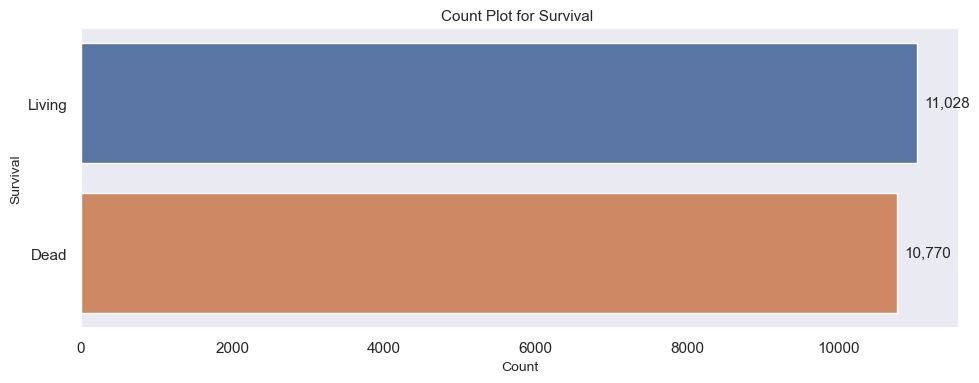

In [6]:
# remove rows where Survival is NaN
df = df.dropna()
# print
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")

# plot
uv.plot_count(df, ['Survival'], fig_size=(10, 4))

#### Unwanted Labels

In [7]:
# remove unwanted labels
removeCols = df_label.column.to_list()

## Ordinal Plots & Engineering

### Ordinal: Heapmap

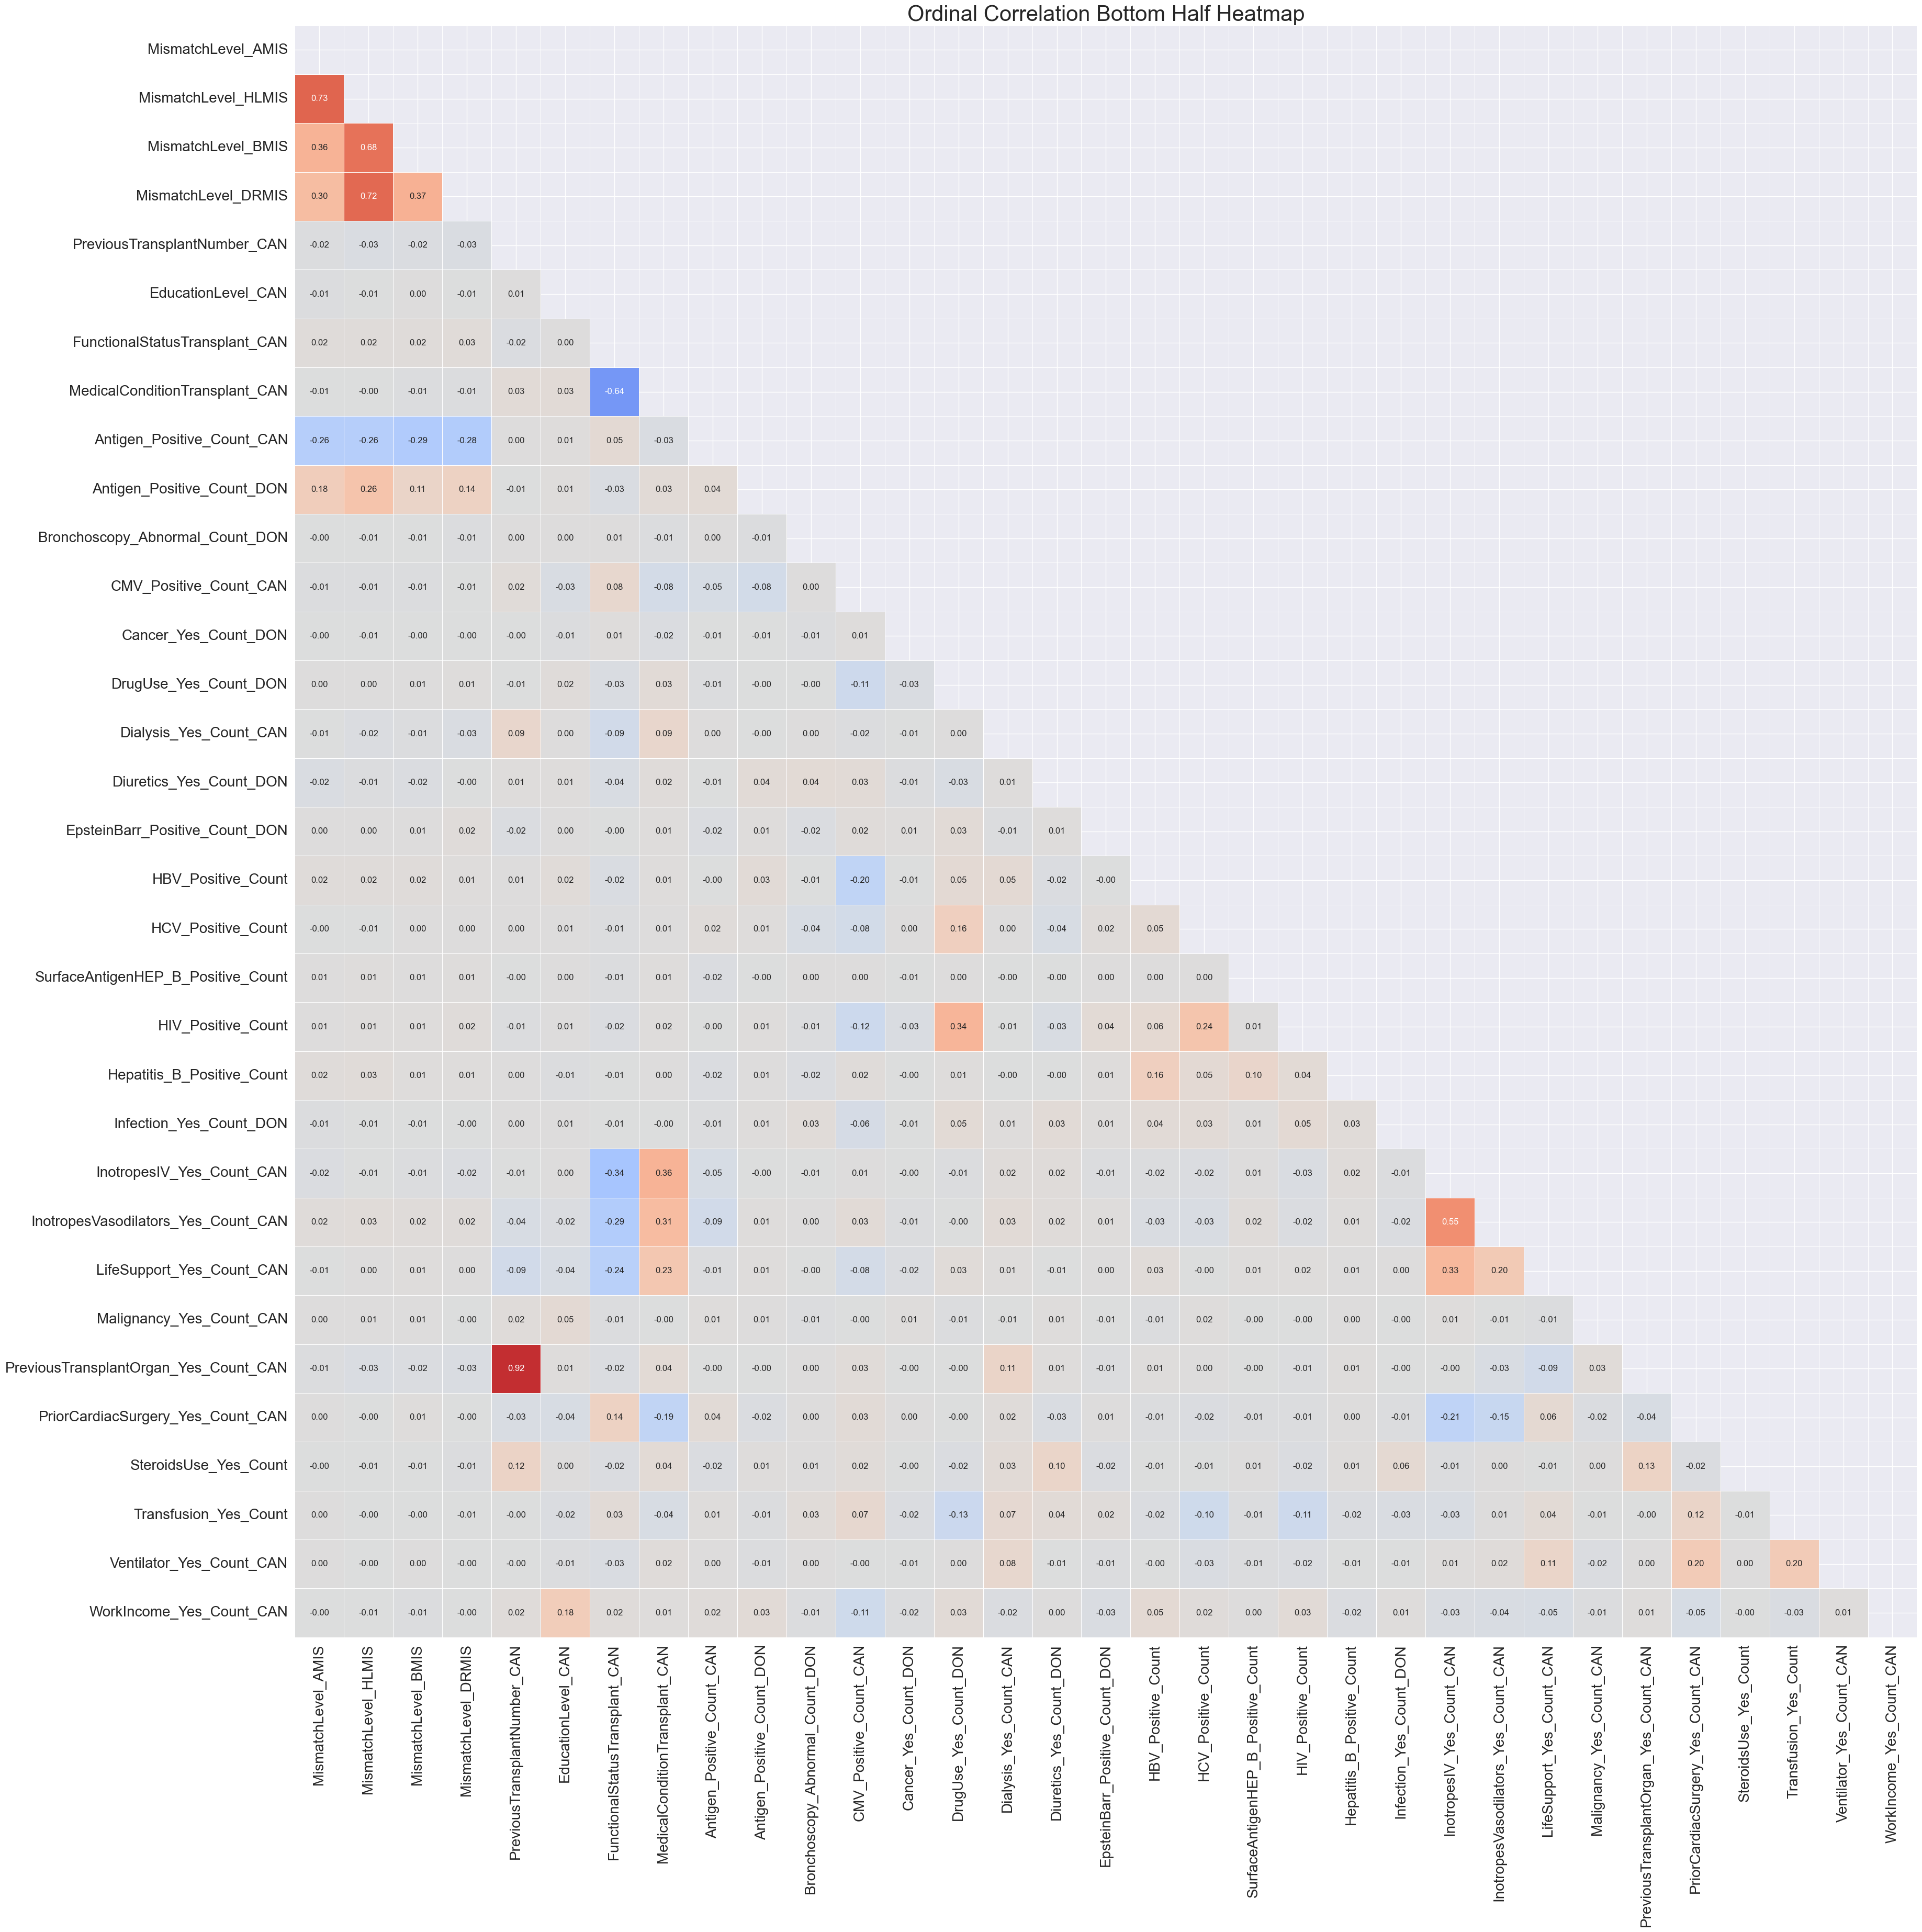

In [8]:
# compute the correlation matrix
corr_matrix = df[df_ordinal.column.to_list()].corr(method='spearman')
# create a mask for the UPPER triangle  
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  

# display options
plt.figure(figsize=(40,40))
plt.title("Ordinal Correlation Bottom Half Heatmap", fontsize=30)
plt.xticks(fontsize=20)  # font size for x-ticks
plt.yticks(fontsize=20)  # font size for y-ticks
# plot the BOTTOM half (lower triangle + diagonal)  
sns.heatmap(corr_matrix,  
            mask=mask,  # hide the upper triangle  
            annot=True,  
            cmap='coolwarm',  
            vmin=-1, vmax=1,  
            linewidths=0.5, fmt=".2f", cbar=False)  
plt.show()

### Ordinal Display & Engineering
- The ordinal features with Spearman correlation below indicate strong to very moderatly strong positive monotonic relationships between the respective variable pairs 
    - Very Strong Associations (|r| ≥ 0.7)
    - Moderate-Strong Associations (0.5 ≤ |r| < 0.7)

In [9]:
# threshold value
threshold = 0.5
# identify upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# find feature columns with correlation greater than 0.7
to_drop = [column for column in upper.columns if any(np.abs(upper[column]) > threshold)]

# display
print(f"Strong correlation: {sorted(to_drop)}\n")
# ordinal correlation: re-check
print(f"Ordinal Correlation Re-Check with Threshold of {threshold * 100}% or greater:")
usf.correlation_with_threshold(df[df_ordinal.column.to_list()], method='spearman', threshold=threshold)

Strong correlation: ['InotropesVasodilators_Yes_Count_CAN', 'MedicalConditionTransplant_CAN', 'MismatchLevel_BMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLMIS', 'PreviousTransplantOrgan_Yes_Count_CAN']

Ordinal Correlation Re-Check with Threshold of 50.0% or greater:
Correlation between MismatchLevel_AMIS and MismatchLevel_HLMIS: 0.733
Correlation between MismatchLevel_HLMIS and MismatchLevel_BMIS: 0.679
Correlation between MismatchLevel_HLMIS and MismatchLevel_DRMIS: 0.717
Correlation between PreviousTransplantNumber_CAN and PreviousTransplantOrgan_Yes_Count_CAN: 0.916
Correlation between FunctionalStatusTransplant_CAN and MedicalConditionTransplant_CAN: -0.638
Correlation between InotropesIV_Yes_Count_CAN and InotropesVasodilators_Yes_Count_CAN: 0.550


#### Engineer: MismatchLevel

In [10]:
features = uf.get_feature_list(df, 'MismatchLevel')

                       count      mean       std  min  25%  50%  75%  max
MismatchLevel_AMIS   21798.0  1.577484  0.727577  0.0  1.0  2.0  2.0  3.0
MismatchLevel_BMIS   21798.0  1.805578  0.598665  0.0  1.0  2.0  2.0  3.0
MismatchLevel_DRMIS  21798.0  1.624644  0.697713  0.0  1.0  2.0  2.0  3.0
MismatchLevel_HLMIS  21798.0  4.844389  1.207137  0.0  4.0  5.0  6.0  7.0

:::: NaN Count:
MismatchLevel_AMIS     0
MismatchLevel_BMIS     0
MismatchLevel_DRMIS    0
MismatchLevel_HLMIS    0


In [11]:
# ordinal correlation
usf.correlation_with_threshold(df[features], method='spearman', threshold=threshold)

Correlation between MismatchLevel_AMIS and MismatchLevel_HLMIS: 0.733
Correlation between MismatchLevel_BMIS and MismatchLevel_HLMIS: 0.679
Correlation between MismatchLevel_DRMIS and MismatchLevel_HLMIS: 0.717


In [12]:
# append to removeCols
removeCols.extend(features)

# combine
df['MismatchLevel_Addition'] = df[features].sum(axis=1)

# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['MismatchLevel_Addition'])
df_both = uf.insert_into_dataframe(df_both, ['MismatchLevel_Addition'])
# display
uf.category_contingency_survival(df, 'MismatchLevel_Addition')

Survival,Dead,Living,Row Total,Dead %,Living %
0.0,4.0,13.0,17.0,23.529412,76.470588
2.0,37.0,44.0,81.0,45.679012,54.320988
4.0,248.0,301.0,549.0,45.173042,54.826958
6.0,1060.0,1133.0,2193.0,48.335613,51.664387
8.0,2546.0,2572.0,5118.0,49.745995,50.254005
10.0,3691.0,3766.0,7457.0,49.497117,50.502883
12.0,2319.0,2280.0,4599.0,50.424005,49.575995
13.0,1.0,0.0,1.0,100.000000,0.000000
14.0,1.0,0.0,1.0,100.000000,0.000000
15.0,0.0,1.0,1.0,0.000000,100.000000


#### Engineer: Inotropes

In [13]:
features = uf.get_feature_list(df, 'Inotropes')

                                       count      mean       std  min  25%  50%   75%   max
InotropesIV_Yes_Count_CAN            21798.0  0.699789  0.814980  0.0  0.0  0.0   1.0   2.0
InotropesVasodilators_Yes_Count_CAN  21798.0  4.014176  4.169784  0.0  0.0  5.0  10.0  10.0

:::: NaN Count:
InotropesIV_Yes_Count_CAN              0
InotropesVasodilators_Yes_Count_CAN    0


In [14]:
# ordinal correlation
usf.correlation_with_threshold(df[features], method='spearman', threshold=threshold)

Correlation between InotropesIV_Yes_Count_CAN and InotropesVasodilators_Yes_Count_CAN: 0.550


In [15]:
# append to removeCols
removeCols.extend(features)

# combine
df['Inotropes_Yes_Count_Addition_CAN'] = df[features].sum(axis=1)

# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['Inotropes_Yes_Count_Addition_CAN'])
df_can = uf.insert_into_dataframe(df_can, ['Inotropes_Yes_Count_Addition_CAN'])
# display
uf.category_contingency_survival(df, 'Inotropes_Yes_Count_Addition_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,4271.0,3847.0,8118.0,52.611481,47.388519
1,615.0,738.0,1353.0,45.454545,54.545455
2,322.0,369.0,691.0,46.599132,53.400868
3,1.0,6.0,7.0,14.285714,85.714286
4,19.0,14.0,33.0,57.575758,42.424242
5,938.0,1216.0,2154.0,43.546890,56.453110
6,1103.0,1291.0,2394.0,46.073517,53.926483
7,522.0,617.0,1139.0,45.829675,54.170325
8,12.0,7.0,19.0,63.157895,36.842105
9,14.0,6.0,20.0,70.000000,30.000000


#### Ordinal Remove

In [16]:
# append to removeCols list
removeCols.extend(find_feature('Bilirubin_CAT', df.columns.to_list()))
removeCols.extend(find_feature('BMI_', df.columns.to_list()))
removeCols.extend(find_feature('PreviousTransplantNumber_CAN', df.columns.to_list())) 
removeCols.extend(find_feature('FunctionalStatusTransplant_CAN', df.columns.to_list()))
removeCols.extend(find_feature('Age_CAT', df.columns.to_list()))
removeCols.extend(find_feature('HeightCm_CAT', df.columns.to_list()))
removeCols.extend(find_feature('WeightKg_CAT', df.columns.to_list()))
removeCols.extend(find_feature('DistanceFromDonorHospitaltoTXCenter_CAT', df.columns.to_list()))
removeCols.extend(find_feature('SGOT_ALT_CAT_DON', df.columns.to_list()))
removeCols.extend(find_feature('SGOT_AST_CAT_DON', df.columns.to_list()))

# remove features
df, df_ordinal, df_nominal, df_can, df_don, df_both, df_numeric = HouseKeeping(df, removeCols, df_ordinal, df_nominal, df_can, df_don, df_both, df_numeric, display=True)

Remove 8 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 3 row(s) from df_numeric DataFrame.
Remove 4 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.

Removed Features: ['BMI_Addition', 'FunctionalStatusTransplant_CAN', 'InotropesIV_Yes_Count_CAN', 'InotropesVasodilators_Yes_Count_CAN', 'LengthOfStay', 'MismatchLevel_AMIS', 'MismatchLevel_BMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLMIS', 'PreviousTransplantNumber_CAN', 'TransplantSurvivalDay']

Total Row(s) & Column(s) Before Removing Column(s): 21,798 & columns: 101
Total Row(s) & Column(s) After Removing Column(s): 21,798 & columns: 90


#### Ordinal Association Testing

In [17]:
print(f"Ordinal Correlation Re-Check with Threshold of {threshold * 100}% or greater:")
usf.correlation_with_threshold(df[df_ordinal.column.to_list()], method='spearman', threshold=threshold)

Ordinal Correlation Re-Check with Threshold of 50.0% or greater:


In [18]:
mwutDF = usf.mannwhitneyu_combinations(df, df_ordinal.column.to_list())

# display p_value >= 0.05
mwutDF[(mwutDF.p_value >= 0.05)]

,column1,column2,U_statistic,p_value
147,Cancer_Yes_Count_DON,SurfaceAntigenHEP_B_Positive_Count,237552987.5,0.931669
104,Bronchoscopy_Abnormal_Count_DON,HBV_Positive_Count,237344316.0,0.787516
33,MedicalConditionTransplant_CAN,Diuretics_Yes_Count_DON,235440858.0,0.081699


##### There are associations, but they are different features representing something different.

#### Ordinal Datatype Update

In [19]:
# change datatype to category
df = uf.convert_to_category(df, df_ordinal.column.to_list(), ordered=True)

## Nominal Plots & Engineering

### Nominal Chi2 Test & Cramer V

In [20]:
# hypothesis testing
nominalDF = usf.multi_independence_category(df, df_nominal.column.to_list())
# display
nominalDF[(nominalDF.p_value <= 0.05) & (nominalDF.cramer_v > .5)]

,column1,column2,chi2,p_value,cramer_v
949,NonHeartBeating_DON,CardiacArrest_DON,21798.000000,0.0,1.000000
910,DeceasedRetyped_DON,CrossMatchDone,22331.167279,0.0,0.715702
333,Diabetes_DON,HypertensionHistory_DON,15096.143705,0.0,0.588450
129,AntiHypertensive_DON,Vasodilators_DON,13490.931399,0.0,0.556285


### Nominal Datatype Update

In [21]:
# change datatype to category
df = uf.convert_to_category(df, df_nominal.column.to_list())

## Dummy Encoding

In [22]:
# shape
print(f"Shape before encoding: {df.shape}")
# encode
df_dummy = pd.get_dummies(df, columns=df_nominal.column.to_list(), drop_first=True)
# print shape
print(f"Shape after encoding: {df_dummy.shape}")
# add columns to list
dummyCols = df_dummy.columns.tolist()
# remove label
dummyCols.remove('Survival')

Shape before encoding: (21798, 90)
Shape after encoding: (21798, 195)


## Display GINI Information

In [23]:
# remove features with GiniPercent
percent = 5
holdDF = ufs.compute_entropy_gini_impurity(df_dummy[dummyCols])
removeCols = holdDF.ColumnName[holdDF.GiniPercent < percent].to_list()
print(f"Number of Features to be removed: {len(removeCols)}")
holdDF.sample(20)

Number of Features to be removed: 62


,ColumnName,NumberOfCategories,Entropy,MaxEntropy,EntropyPercent,GiniImpurity,MaxGiniImpurity,GiniPercent
176,CoronaryAngiogram_DON_Unknown,2,0.953679,1.000000,95.367854,0.468238,0.500000,93.647510
64,PrimaryDiagnosisType_CAN_DILATED MYOPATHY: POST PARTUM,2,0.097674,1.000000,9.767403,0.024913,0.500000,4.982671
59,PrimaryDiagnosisType_CAN_DILATED MYOPATHY: FAMILIAL,2,0.224570,1.000000,22.457040,0.069772,0.500000,13.954333
99,DefibrillatorImplantRegistration_CAN_Unknown,2,0.082013,1.000000,8.201326,0.020161,0.500000,4.032279
114,Ethnicity_CAN_Black,2,0.779485,1.000000,77.948466,0.355113,0.500000,71.022636
124,"Ethnicity_DON_White, Non-Hispanic",2,0.940558,1.000000,94.055795,0.459367,0.500000,91.873394
118,"Ethnicity_CAN_White, Non-Hispanic",2,0.945380,1.000000,94.538046,0.462621,0.500000,92.524173
46,AntiHypertensive_DON_Unknown,2,0.003652,1.000000,0.365247,0.000550,0.500000,0.110072
33,Malignancy_Yes_Count_CAN,3,0.447784,1.584963,28.252033,0.166925,0.666667,25.038755
3,BloodUreaNitrogenLevel_DON,203,5.659135,7.665336,73.827624,0.972285,0.995074,97.709795


In [24]:
# features to be removed
holdDF[holdDF.ColumnName.isin(removeCols)].sample(10)

,ColumnName,NumberOfCategories,Entropy,MaxEntropy,EntropyPercent,GiniImpurity,MaxGiniImpurity,GiniPercent
51,PrimaryDiagnosisType_CAN_CONGENITAL HEART DEFECT - PRIOR SURGERY UNKNOWN,2,0.006255,1.0,0.625483,0.001009,0.50,0.201752
95,DiabetesType_CAN_Unknown,2,0.006754,1.0,0.675433,0.001100,0.50,0.220082
142,PriorLungSurgeryAfterRegistration_CAN_Yes,2,0.038281,1.0,3.828135,0.008133,0.50,1.626509
84,PrimaryDiagnosisType_CAN_RESTRICTIVE MYOPATHY: SEC TO RADIAT/CHEM,2,0.023417,1.0,2.341749,0.004577,0.50,0.915411
58,PrimaryDiagnosisType_CAN_DILATED MYOPATHY: ALCOHOLIC,2,0.027766,1.0,2.776551,0.005581,0.50,1.116236
21,Cancer_Yes_Count_DON,4,0.120249,2.0,6.012469,0.028727,0.75,3.830242
66,PrimaryDiagnosisType_CAN_DILATED MYOPATHY: VIRAL (NOT COVID-19),2,0.017644,1.0,1.764407,0.003298,0.50,0.659520
93,Diabetes_DON_Unknown,2,0.053325,1.0,5.332461,0.012038,0.50,2.407572
82,PrimaryDiagnosisType_CAN_RESTRICTIVE MYOPATHY: OTHER SPECIFY,2,0.030080,1.0,3.007990,0.006128,0.50,1.225692
181,HypertensionHistory_DON_Unknown,2,0.061616,1.0,6.161572,0.014301,0.50,2.860248


## Split Dataset

In [25]:
from sklearn.model_selection import train_test_split

# encoded DataFrame
df_dummy = df_dummy.drop(columns=removeCols)
# print shape
print(f"Encode & Remove Features with GINI: Heart Dataset Rows: {df_dummy.shape[0]:,} & Columns: {df_dummy.shape[1]:,}")

# house keeping
ordinalCols = list(set(df_ordinal.column.to_list()) - set(removeCols))

# split X & y
X = df_dummy.drop(columns = 'Survival')
y = df_dummy.Survival

# mapping values
y = y.map({'Dead': True, 'Living': False}).astype(int)
# print
print(f"Dead: {True} & Living: {False}")

# split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

Encode & Remove Features with GINI: Heart Dataset Rows: 21,798 & Columns: 133
Dead: True & Living: False


## Scale

In [26]:
from sklearn.preprocessing import MinMaxScaler

# add numeric features to scale
scaleAll = ordinalCols + df_numeric.column.to_list() 

# initialize MinMaxScaler
scale = MinMaxScaler()

# fit
fitScale = scale.fit(X_train[scaleAll])

# transform
X_train[scaleAll] = fitScale.transform(X_train[scaleAll])
X_test[scaleAll] = fitScale.transform(X_test[scaleAll])

In [27]:
# message for dataframe
msg = f"2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < {percent}% removed"

## Custom Score Function

Youden’s J statistic (also called Youden’s Index) is a single-number summary of a binary classification model’s performance. It balances sensitivity (recall for positive class) and specificity (recall for negative class).
- `Youden’s J=Sensitivity + Specificity − 1`

In [28]:
from sklearn.metrics import confusion_matrix, make_scorer, matthews_corrcoef

def youdens_j_score(y_true, y_pred):
    """
    Compute Youden's J statistic.
    J = Sensitivity + Specificity - 1
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return sensitivity + specificity - 1


# define MCC scorer
mcc_scorer = make_scorer(matthews_corrcoef)

# scikit-learn scorer
youden_scorer = make_scorer(youdens_j_score, greater_is_better=True)

# define MCC scorer
mcc_scorer = make_scorer(matthews_corrcoef)

## Machine Learning

### RandomForestClassifier

In [29]:
from sklearn.ensemble import RandomForestClassifier
# function from sklearn.utils.class_weight computes the weights for each class to handle imbalanced datasets
from sklearn.utils.class_weight import compute_class_weight

# the 'balanced' mode adjusts weights inversely proportional to class frequencies in the input data for Random Forest
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

# define the search space
search_space = parms.rfc_search_space()

# Initialize Model with class weights
rfc_param = {'random_state': RANDOM_STATE}

# instantiate Random Forest Classifier
Model = RandomForestClassifier(**rfc_param)

# Hyper-Parameter tuning
rfc_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, youden_scorer, n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = rfc_fit

Best parameters found: OrderedDict([('max_depth', 10), ('max_features', 'sqrt'), ('min_samples_split', 11), ('n_estimators', 346)])
Best score achieved: 0.688596081134895

Current Model Parameters:
 RandomForestClassifier(max_depth=10, min_samples_split=11, n_estimators=346,
                       random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.98      0.87      8822
           1       0.97      0.72      0.83      8616

    accuracy                           0.85     17438
   macro avg       0.88      0.85      0.85     17438
weighted avg       0.88      0.85      0.85     17438



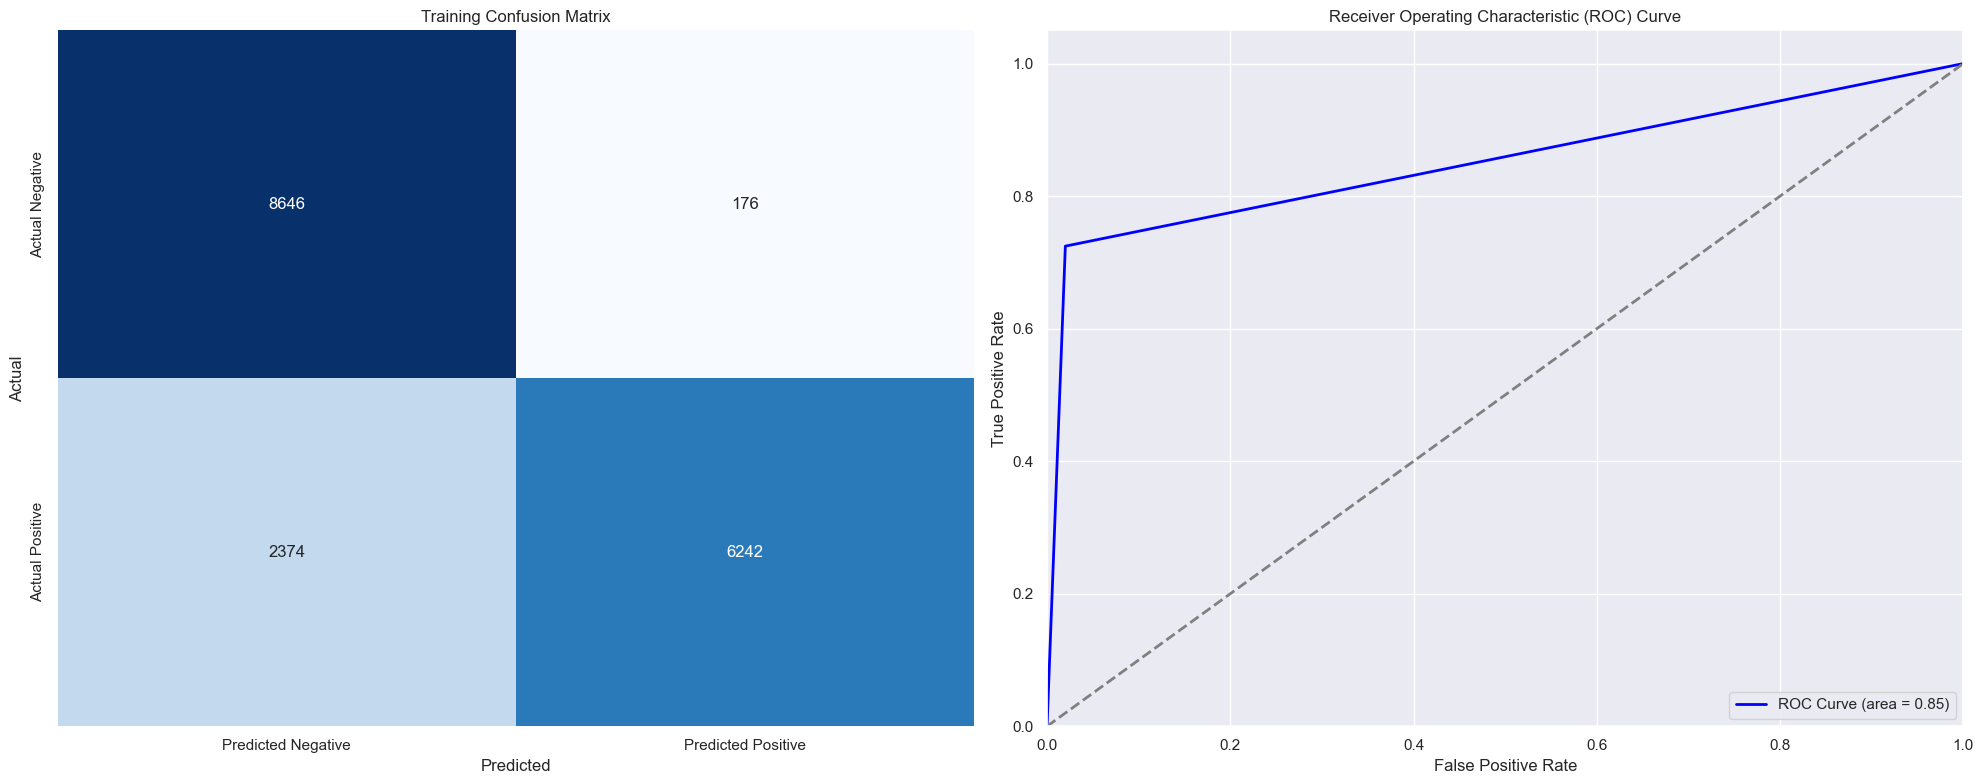

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.853768,0.724466,0.830384,0.840739,0.972577,0.98005,0.852258


In [30]:
# initialize variables
algorithm = 'RandomForestClassifier'
desc = f'{algorithm} - {msg}'
model = 'rfc_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=None, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.97      0.86      2206
           1       0.96      0.71      0.81      2154

    accuracy                           0.84      4360
   macro avg       0.87      0.84      0.84      4360
weighted avg       0.86      0.84      0.84      4360



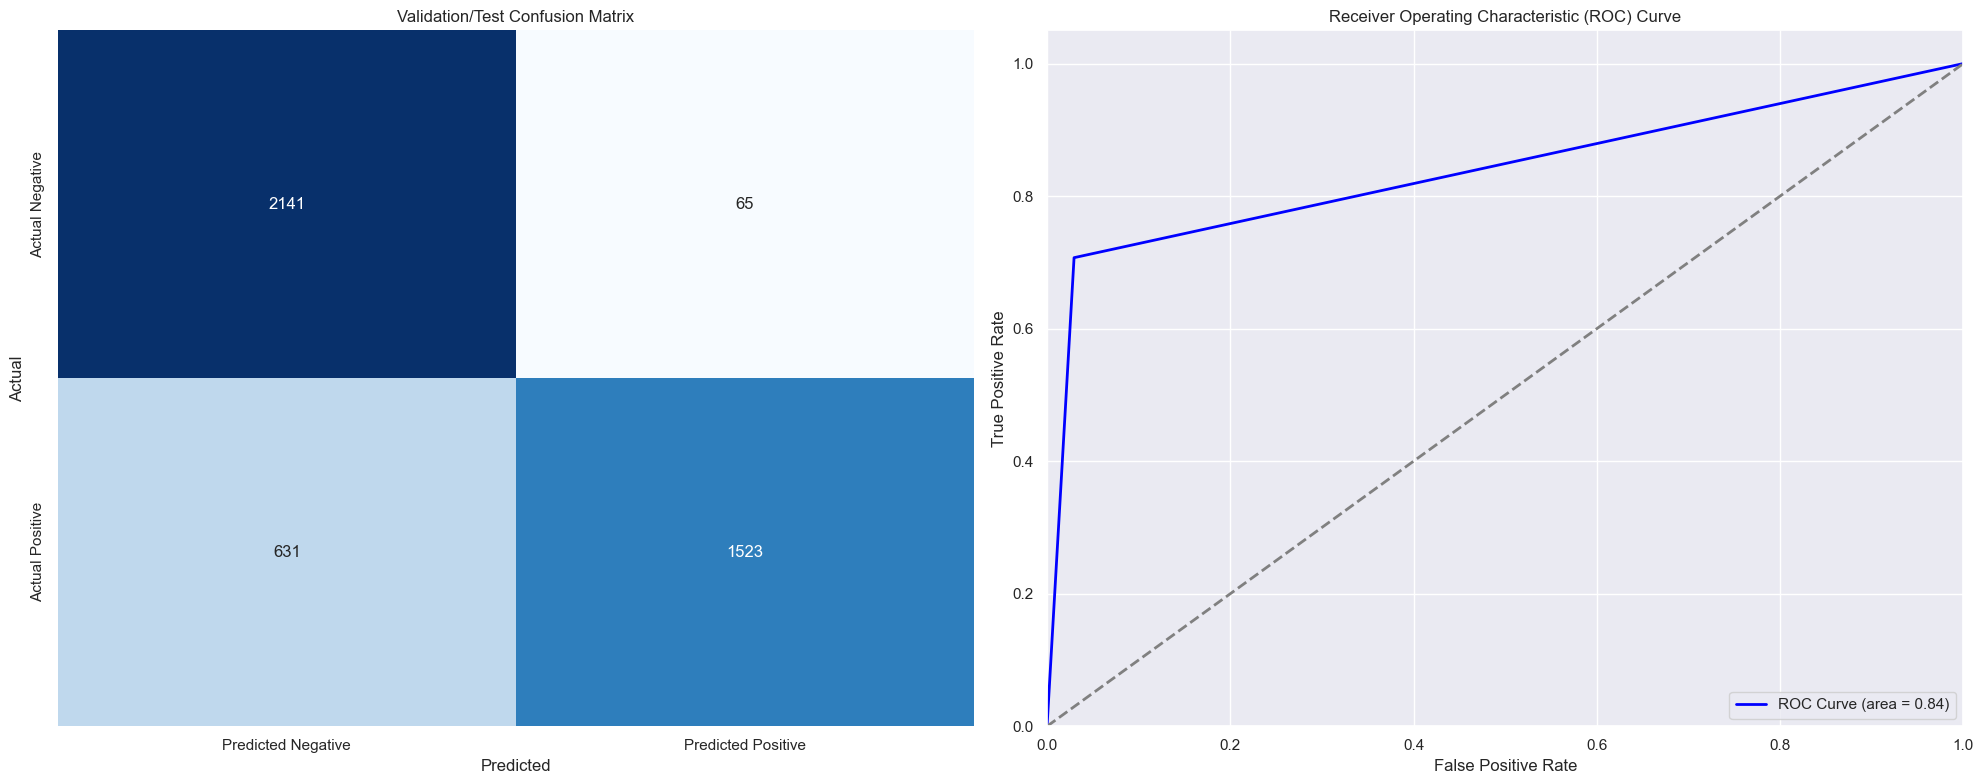

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.853768,0.724466,0.830384,0.840739,0.972577,0.980050,0.852258
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.840367,0.707057,0.814003,0.822840,0.959068,0.970535,0.838796


In [31]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type,  metric_df=df_classfication, train_threshold=None)
df_classfication

#### Feature Importance

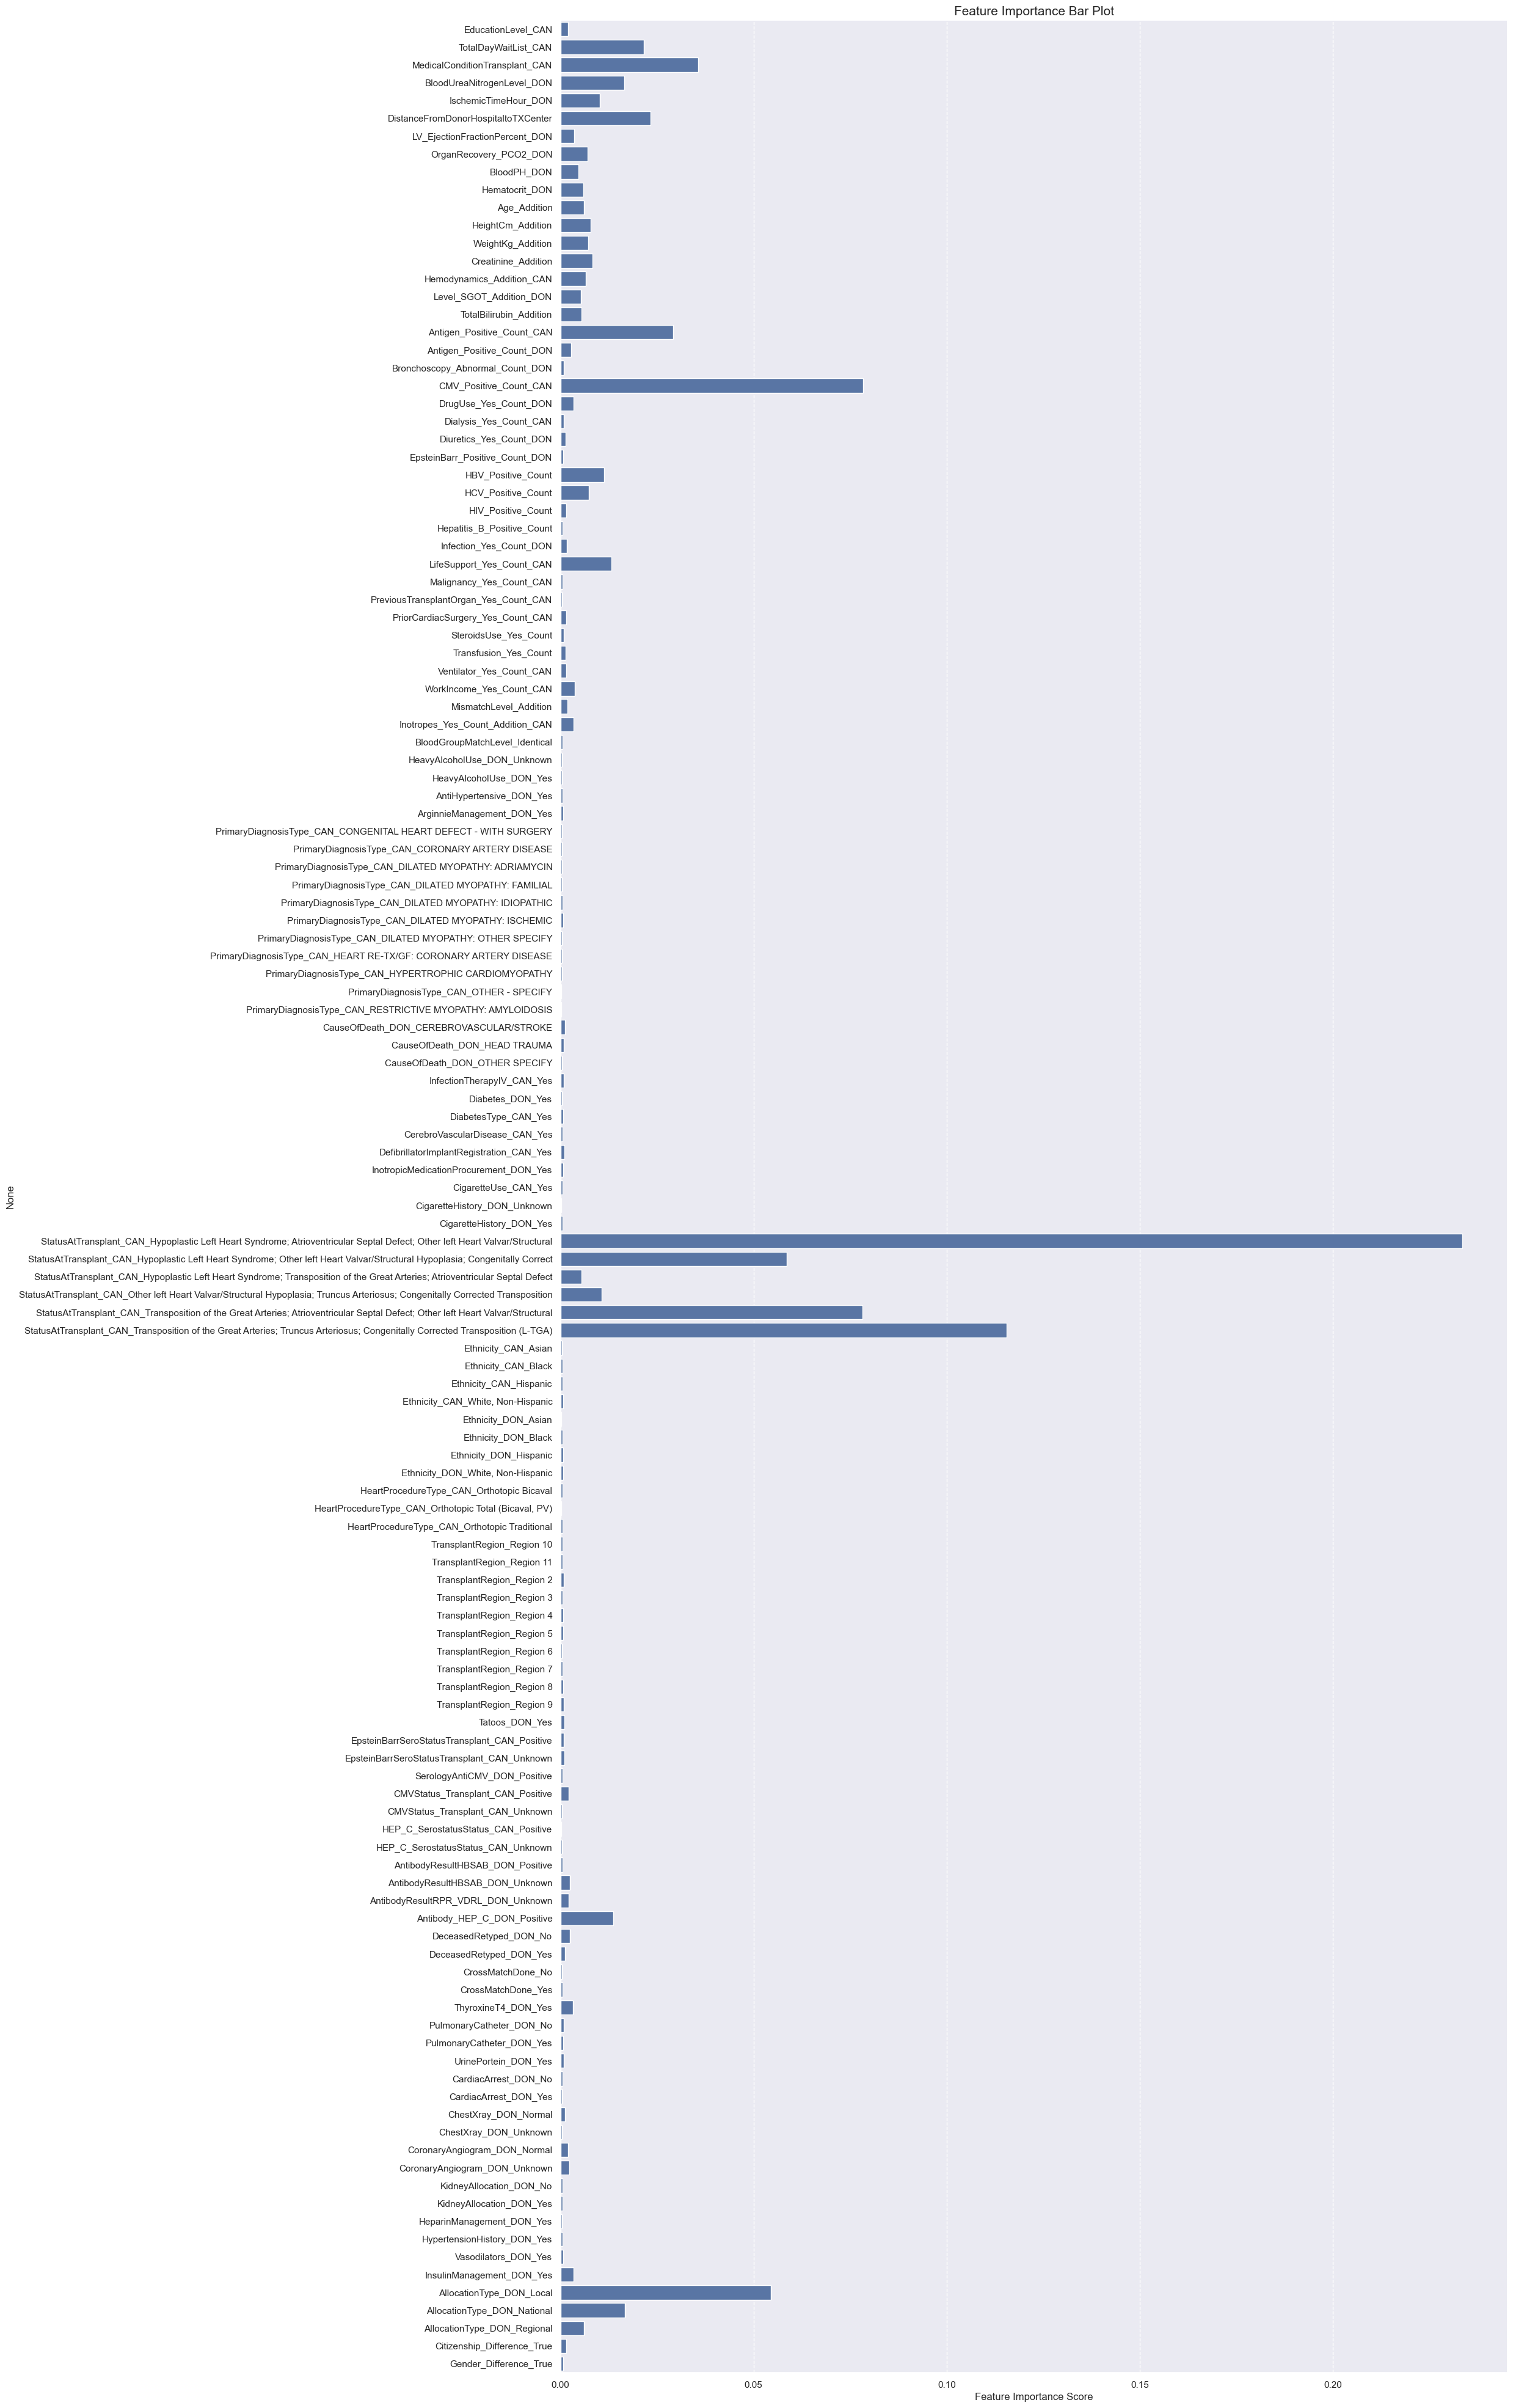

In [32]:
df_rfc = umf.plot_feature_importance(Model, pd.DataFrame(X_train, columns=X_train.columns.to_list()),figsize=(20,50))

In [33]:
df_rfc.sort_values(by='Feature Importance Score', ascending=False).head(20)

,Feature Importance Score
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.233488
StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),0.115594
CMV_Positive_Count_CAN,0.078294
StatusAtTransplant_CAN_Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.078264
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct,0.058598
AllocationType_DON_Local,0.054475
MedicalConditionTransplant_CAN,0.035664
Antigen_Positive_Count_CAN,0.029110
DistanceFromDonorHospitaltoTXCenter,0.023370
TotalDayWaitList_CAN,0.021540


### LogisticRegression

In [34]:
# import library
from sklearn.linear_model import LogisticRegression

# define the search space
search_space = parms.lrc_search_space()

# Base Model
lrc_param = {'max_iter':10000, 'random_state': RANDOM_STATE, 'solver': 'saga', 'penalty': 'elasticnet'}

# instantiate LogisticRegression Classifier
Model = LogisticRegression(**lrc_param)

# Hyper-Parameter tuning
lrc_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, youden_scorer, n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = lrc_fit

Best parameters found: OrderedDict([('C', 0.9572065075718629), ('class_weight', None), ('l1_ratio', 1.0)])
Best score achieved: 0.6874117008104585

Current Model Parameters:
 LogisticRegression(C=0.9572065075718629, l1_ratio=1.0, max_iter=10000,
                   penalty='elasticnet', random_state=1776, solver='saga')


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.97      0.86      8822
           1       0.96      0.72      0.82      8616

    accuracy                           0.85     17438
   macro avg       0.87      0.84      0.84     17438
weighted avg       0.87      0.85      0.84     17438



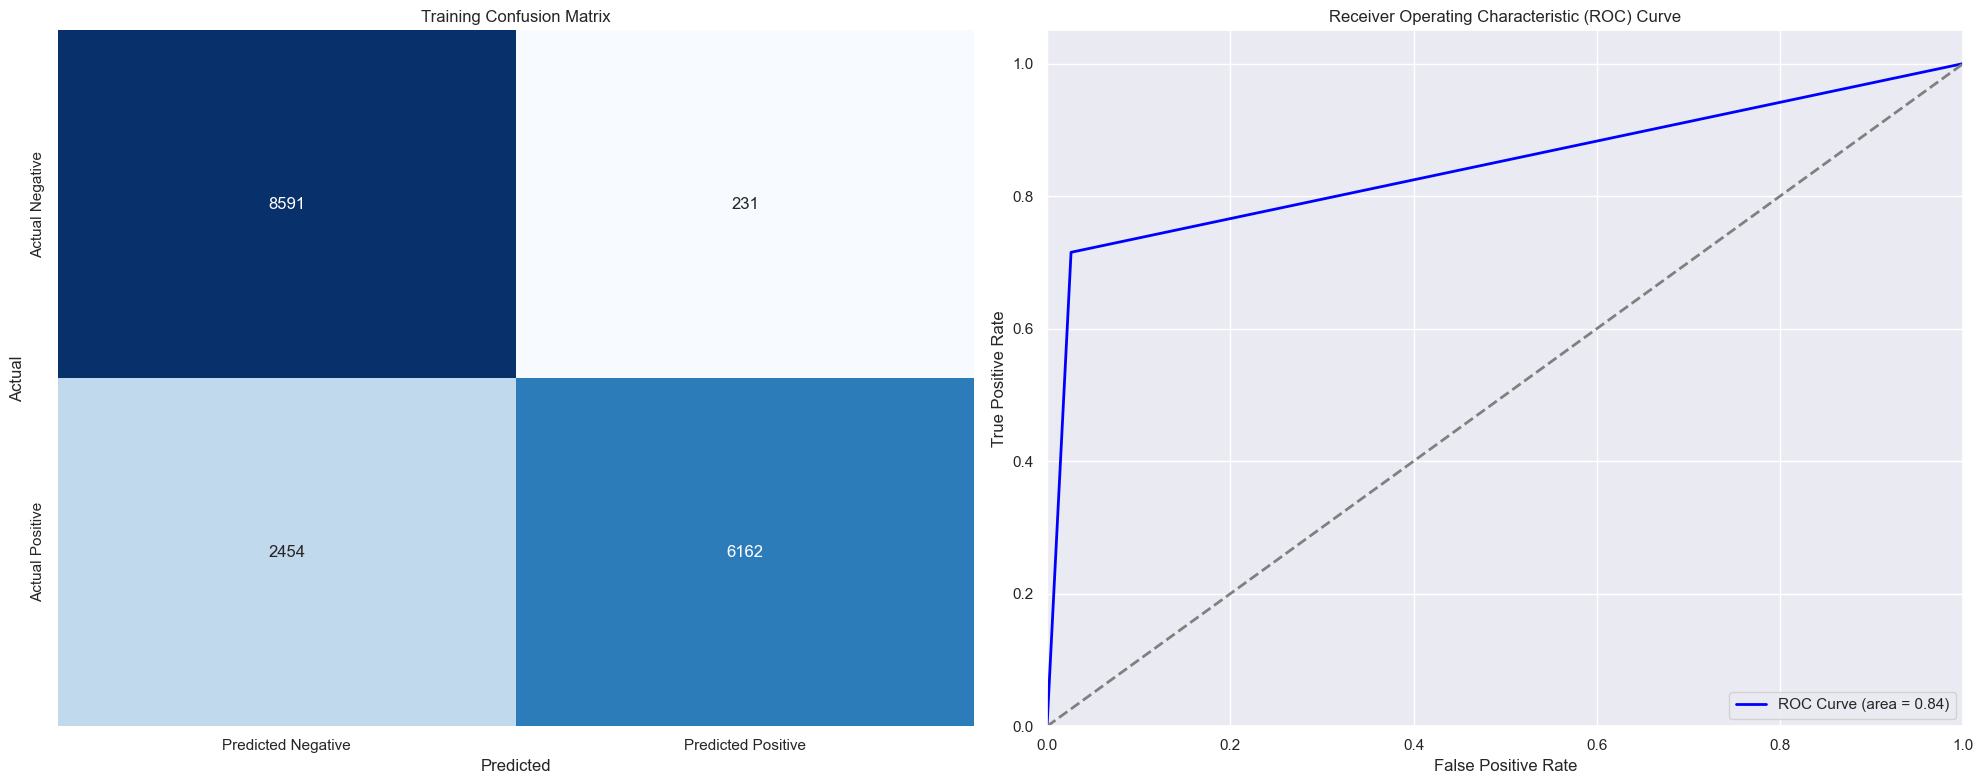

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.853768,0.724466,0.830384,0.840739,0.972577,0.980050,0.852258
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.840367,0.707057,0.814003,0.822840,0.959068,0.970535,0.838796
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846026,0.715181,0.821107,0.830066,0.963867,0.973815,0.844498


In [35]:
# initialize variables
algorithm = 'LogisticRegression'
desc = f'{algorithm} - {msg}'
model = 'lrc_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.97      0.86      2206
           1       0.96      0.71      0.81      2154

    accuracy                           0.84      4360
   macro avg       0.87      0.84      0.84      4360
weighted avg       0.87      0.84      0.84      4360



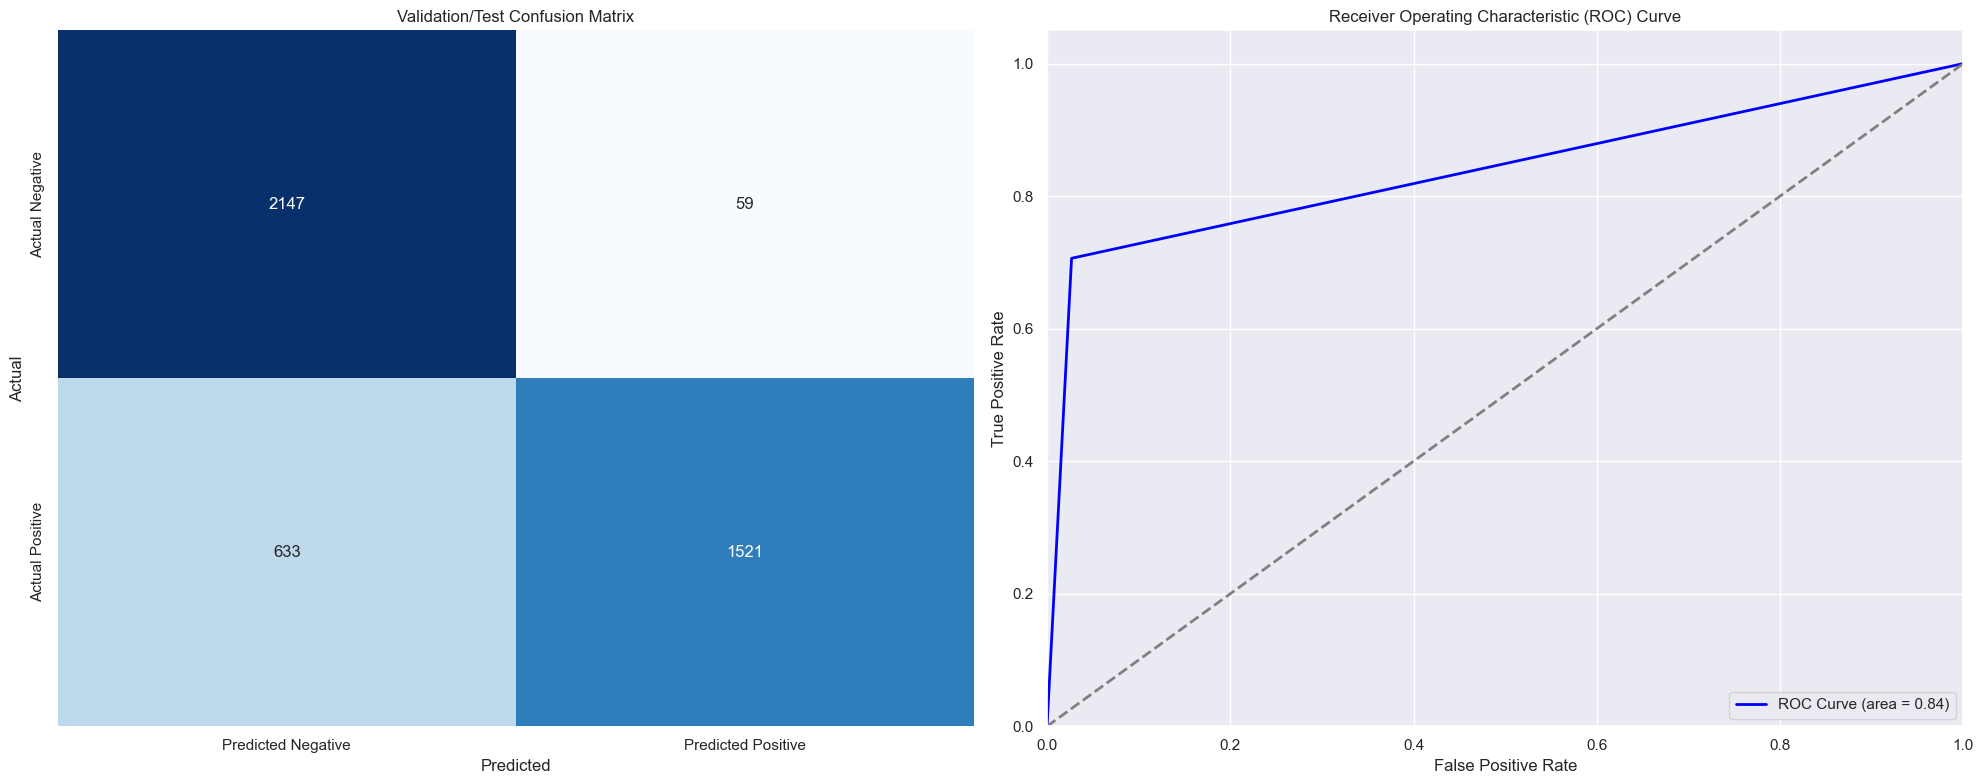

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.853768,0.724466,0.830384,0.840739,0.972577,0.980050,0.852258
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.840367,0.707057,0.814003,0.822840,0.959068,0.970535,0.838796
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846026,0.715181,0.821107,0.830066,0.963867,0.973815,0.844498
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841284,0.706128,0.814676,0.824944,0.962658,0.973255,0.839691


In [36]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Feature Importance

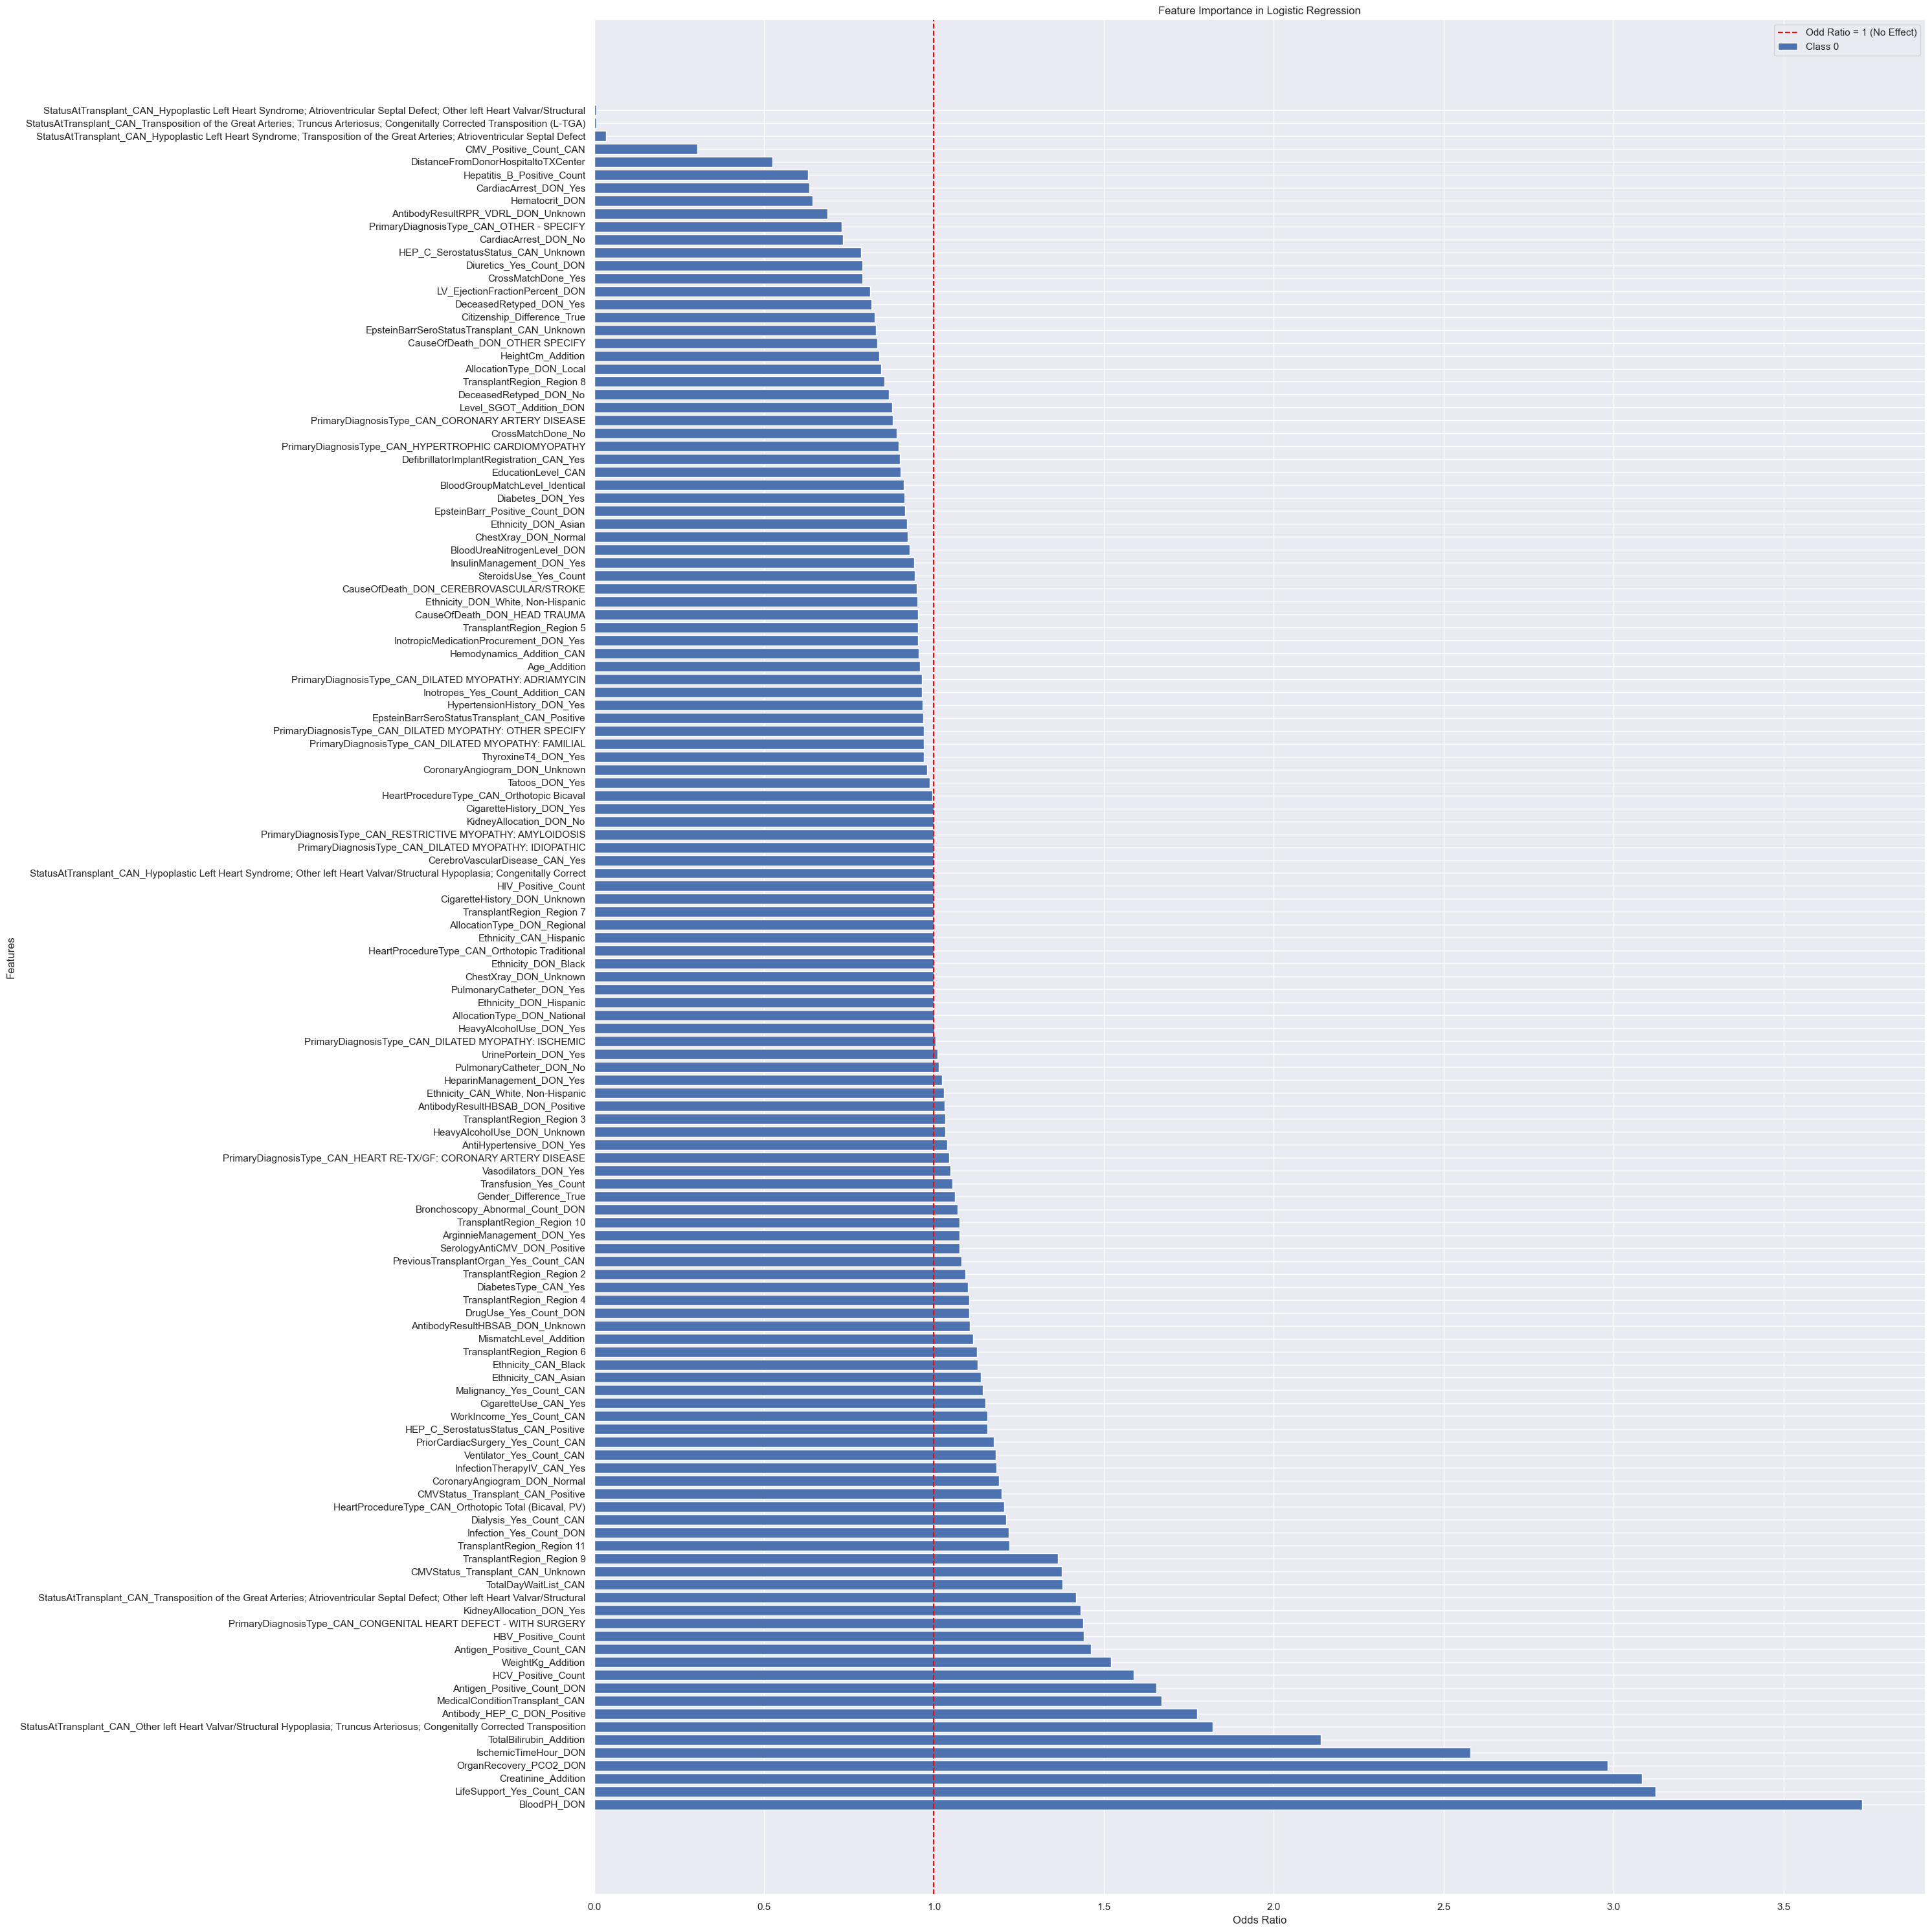

In [37]:
df_lrc = umf.logistic_feature_importance(Model, figsize=(30,30), fontsize=6)

In [38]:
df_lrc.sort_values(by='Coefficient', ascending=False).head(20)

,Feature,Coefficient,Description,Odd Ratio,Percentage Change in Odds,Probability,Class
0,BloodPH_DON,1.316757,Increase in the log-odds of the Positive Class,3.731300,273.130001,0.788642,Class 0
1,LifeSupport_Yes_Count_CAN,1.138833,Increase in the log-odds of the Positive Class,3.123122,212.312185,0.757465,Class 0
2,Creatinine_Addition,1.125972,Increase in the log-odds of the Positive Class,3.083212,208.321151,0.755095,Class 0
3,OrganRecovery_PCO2_DON,1.092665,Increase in the log-odds of the Positive Class,2.982210,198.220978,0.748883,Class 0
4,IschemicTimeHour_DON,0.947265,Increase in the log-odds of the Positive Class,2.578647,157.864669,0.720565,Class 0
5,TotalBilirubin_Addition,0.760342,Increase in the log-odds of the Positive Class,2.139008,113.900796,0.681428,Class 0
6,StatusAtTransplant_CAN_Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosus; Congenitally Corrected Transposition,0.599206,Increase in the log-odds of the Positive Class,1.820673,82.067292,0.645475,Class 0
7,Antibody_HEP_C_DON_Positive,0.573007,Increase in the log-odds of the Positive Class,1.773592,77.359229,0.639457,Class 0
8,MedicalConditionTransplant_CAN,0.512359,Increase in the log-odds of the Positive Class,1.669224,66.922356,0.625359,Class 0
9,Antigen_Positive_Count_DON,0.502985,Increase in the log-odds of the Positive Class,1.653650,65.364989,0.623161,Class 0


### XGBClassifier

#### Explanation of the Gamma Parameter
- In XGBoost, the regularization term that controls the minimum loss reduction required to make a split at a node is known as the "gamma" parameter. This parameter plays a crucial role in the decision-making process of the algorithm during the tree construction phase.
- Definition: The gamma parameter specifies the minimum loss reduction required to make a further partition on a leaf node of the tree. If the reduction in loss from making a split is less than gamma, then that split will not be made.
- Purpose: By setting a higher value for gamma, you can prevent overfitting by making the model more conservative. It effectively controls how complex the model can become by limiting the number of splits. A lower gamma allows more splits and can lead to a more complex model.
- Impact on Model Complexity:
    - High Gamma Value: Results in fewer splits, leading to simpler trees that may underfit the data.
    - Low Gamma Value: Allows more splits, potentially leading to more complex trees that may overfit the training data.

The gamma parameter is essential for controlling the complexity of models built using XGBoost by regulating how much improvement in loss is necessary for splitting nodes. Adjusting this parameter can help balance between bias and variance, thus improving model performance on unseen data.

In [39]:
# import library
from xgboost import XGBClassifier

# calculate the scale_pos_weight to adjust for class imbalance
# helps to counteract the imbalance by giving more weight to the minority class (usually the positive class in binary classification).
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

# define the search space
search_space = parms.xgbc_search_space(scale_pos_weight)

# Base Model
xgb_param = {'random_state': RANDOM_STATE}

# instantiate XGB Classifier
Model = XGBClassifier(**xgb_param)

# Hyper-Parameter tuning
xgb_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, youden_scorer, n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = xgb_fit

Best parameters found: OrderedDict([('colsample_bytree', 0.8871694924423275), ('gamma', 2.4757057319592533), ('learning_rate', 0.012494731285515984), ('max_depth', 7), ('n_estimators', 392), ('scale_pos_weight', 1.004566212568195), ('subsample', 0.9675211553037656)])
Best score achieved: 0.6934883879292519

Current Model Parameters:
 XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8871694924423275, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=2.4757057319592533,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.012494731285515984,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monoton

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.99      0.88      8822
           1       0.99      0.73      0.84      8616

    accuracy                           0.86     17438
   macro avg       0.89      0.86      0.86     17438
weighted avg       0.89      0.86      0.86     17438



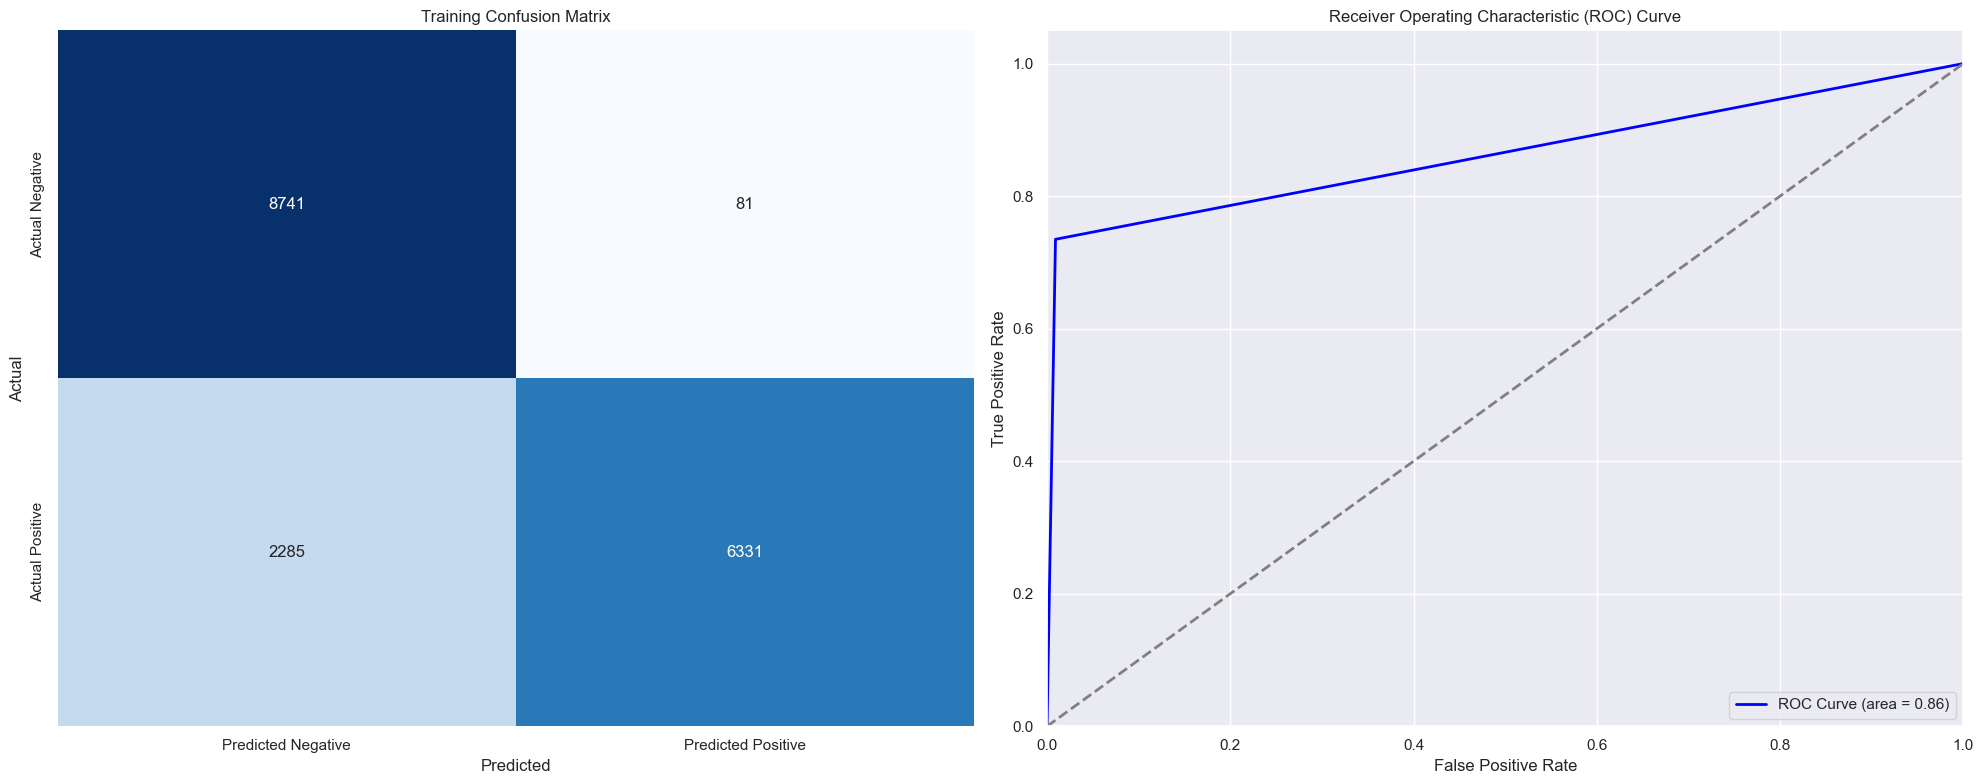

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.853768,0.724466,0.830384,0.840739,0.972577,0.980050,0.852258
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.840367,0.707057,0.814003,0.822840,0.959068,0.970535,0.838796
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846026,0.715181,0.821107,0.830066,0.963867,0.973815,0.844498
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841284,0.706128,0.814676,0.824944,0.962658,0.973255,0.839691
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.864319,0.734796,0.842561,0.856549,0.987367,0.990818,0.862807


In [40]:
# initialize variables
algorithm = 'XGBClassifier'
desc = f'{algorithm} - {msg}'
model = 'xgb_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.99      0.87      2206
           1       0.98      0.70      0.82      2154

    accuracy                           0.84      4360
   macro avg       0.88      0.84      0.84      4360
weighted avg       0.87      0.84      0.84      4360



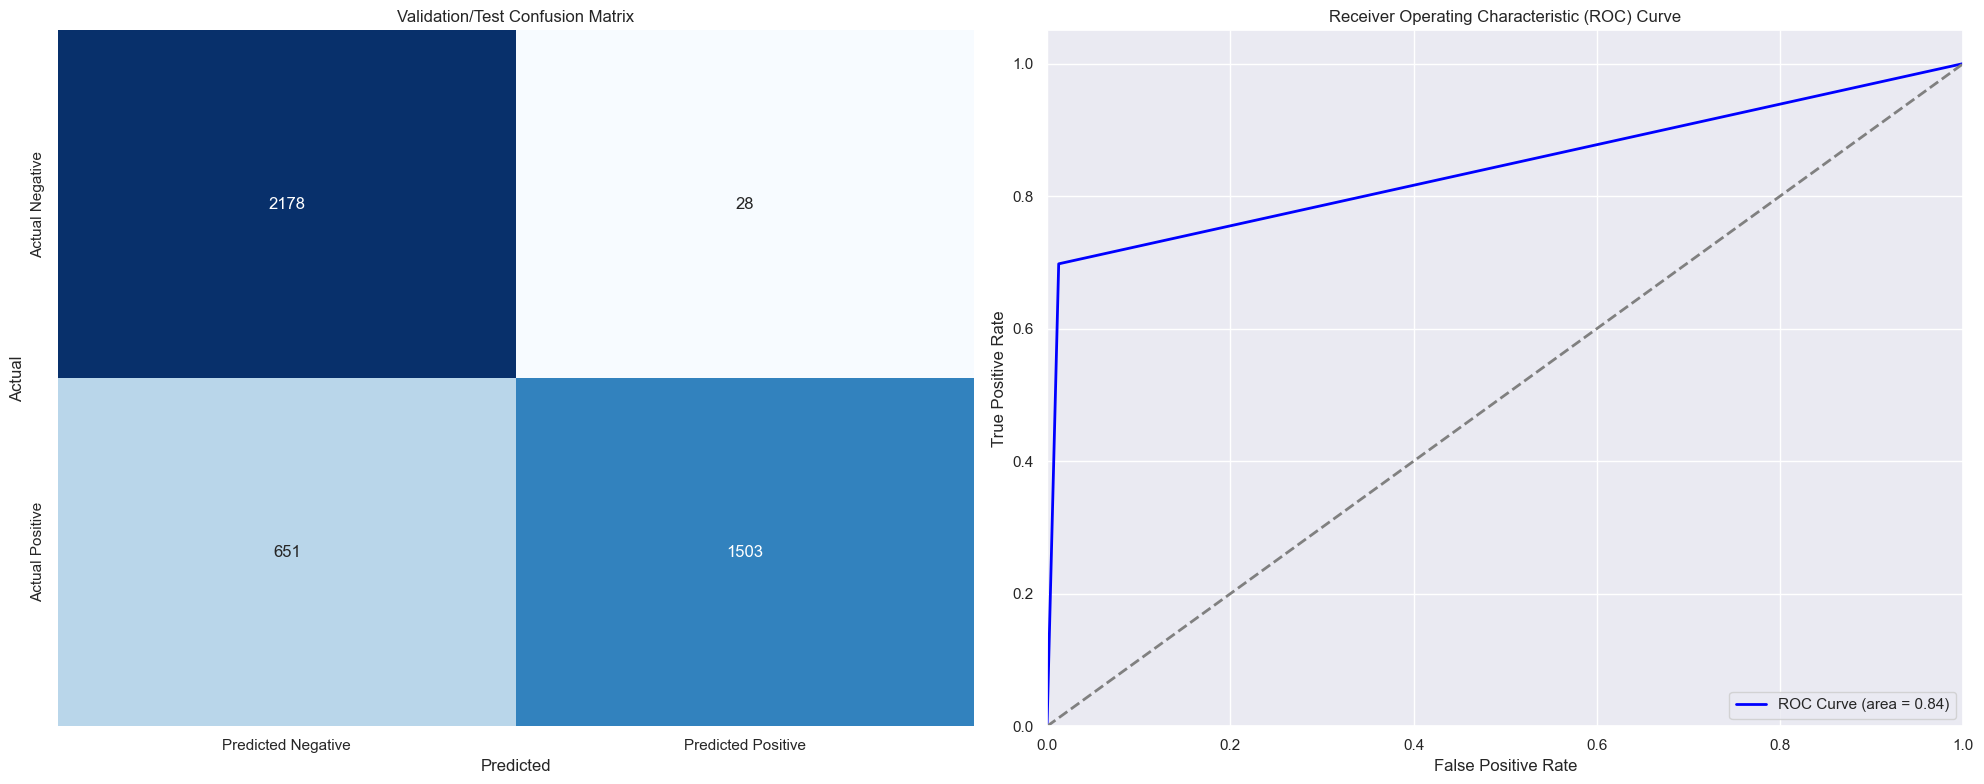

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.853768,0.724466,0.830384,0.840739,0.972577,0.980050,0.852258
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.840367,0.707057,0.814003,0.822840,0.959068,0.970535,0.838796
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846026,0.715181,0.821107,0.830066,0.963867,0.973815,0.844498
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841284,0.706128,0.814676,0.824944,0.962658,0.973255,0.839691
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.864319,0.734796,0.842561,0.856549,0.987367,0.990818,0.862807
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.844266,0.697772,0.815739,0.834322,0.981711,0.987307,0.842539


In [41]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Feature Importance

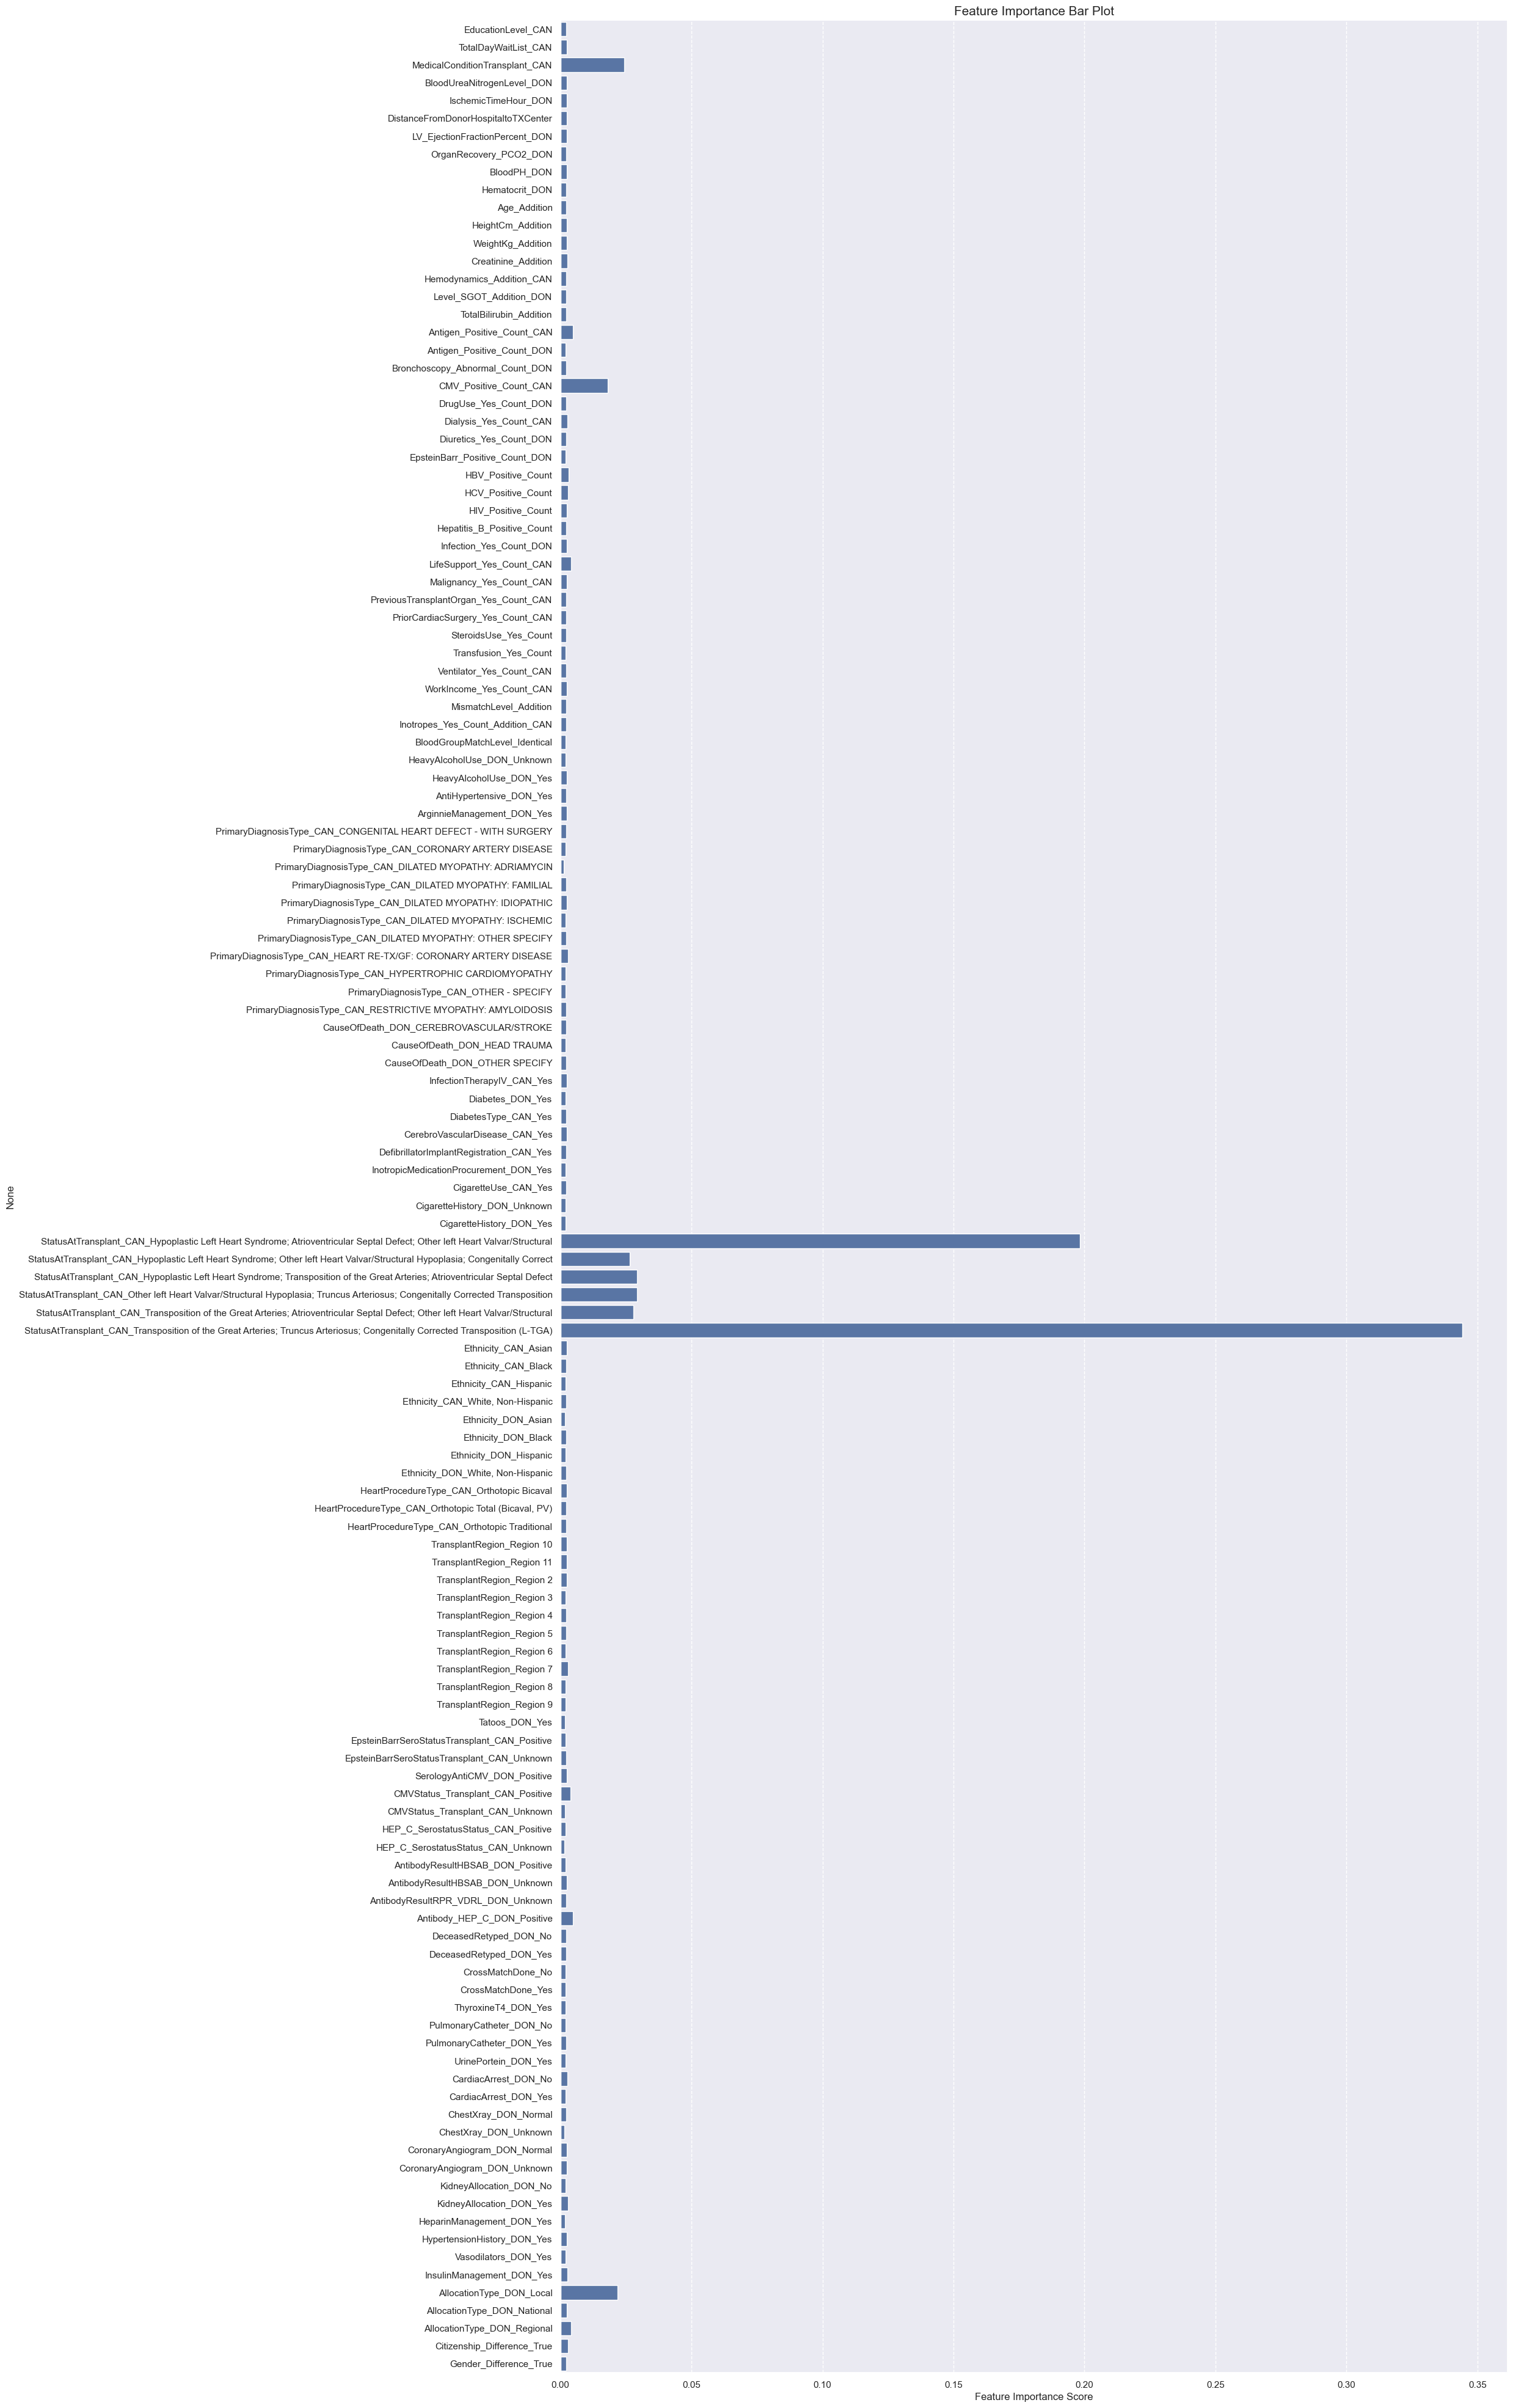

In [42]:
df_xgb = umf.plot_feature_importance(Model, pd.DataFrame(X_train, columns=X_train.columns.to_list()),figsize=(20,50))

In [43]:
df_xgb.sort_values(by = 'Feature Importance Score', ascending=False).head(20)

,Feature Importance Score
StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),0.344184
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.198303
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect,0.029160
StatusAtTransplant_CAN_Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosus; Congenitally Corrected Transposition,0.029117
StatusAtTransplant_CAN_Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.027807
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct,0.026431
MedicalConditionTransplant_CAN,0.024280
AllocationType_DON_Local,0.021760
CMV_Positive_Count_CAN,0.018109
Antibody_HEP_C_DON_Positive,0.004851


### KNN
- `K-Nearest Neighbors (KNN)`
    - Type: Instance-based learning (lazy learning)
    - Mechanism: Classifies a data point based on the majority class among its k-nearest neighbors.
    - Pros: Simple, intuitive, no training phase.
    - Cons: Computationally expensive during prediction, sensitive to irrelevant features and the choice of k.

In [44]:
# import library
from sklearn.neighbors import KNeighborsClassifier

# define the search space
search_space = parms.knn_search_space()

# create a KNN model
Model = KNeighborsClassifier(n_jobs=-1)

# Hyper-Parameter tuning
knn_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, youden_scorer, n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = knn_fit

Best parameters found: OrderedDict([('leaf_size', 50), ('n_neighbors', 20), ('p', 1), ('weights', 'distance')])
Best score achieved: 0.5754128809099492

Current Model Parameters:
 KNeighborsClassifier(leaf_size=50, n_jobs=-1, n_neighbors=20, p=1,
                     weights='distance')


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8822
           1       1.00      1.00      1.00      8616

    accuracy                           1.00     17438
   macro avg       1.00      1.00      1.00     17438
weighted avg       1.00      1.00      1.00     17438



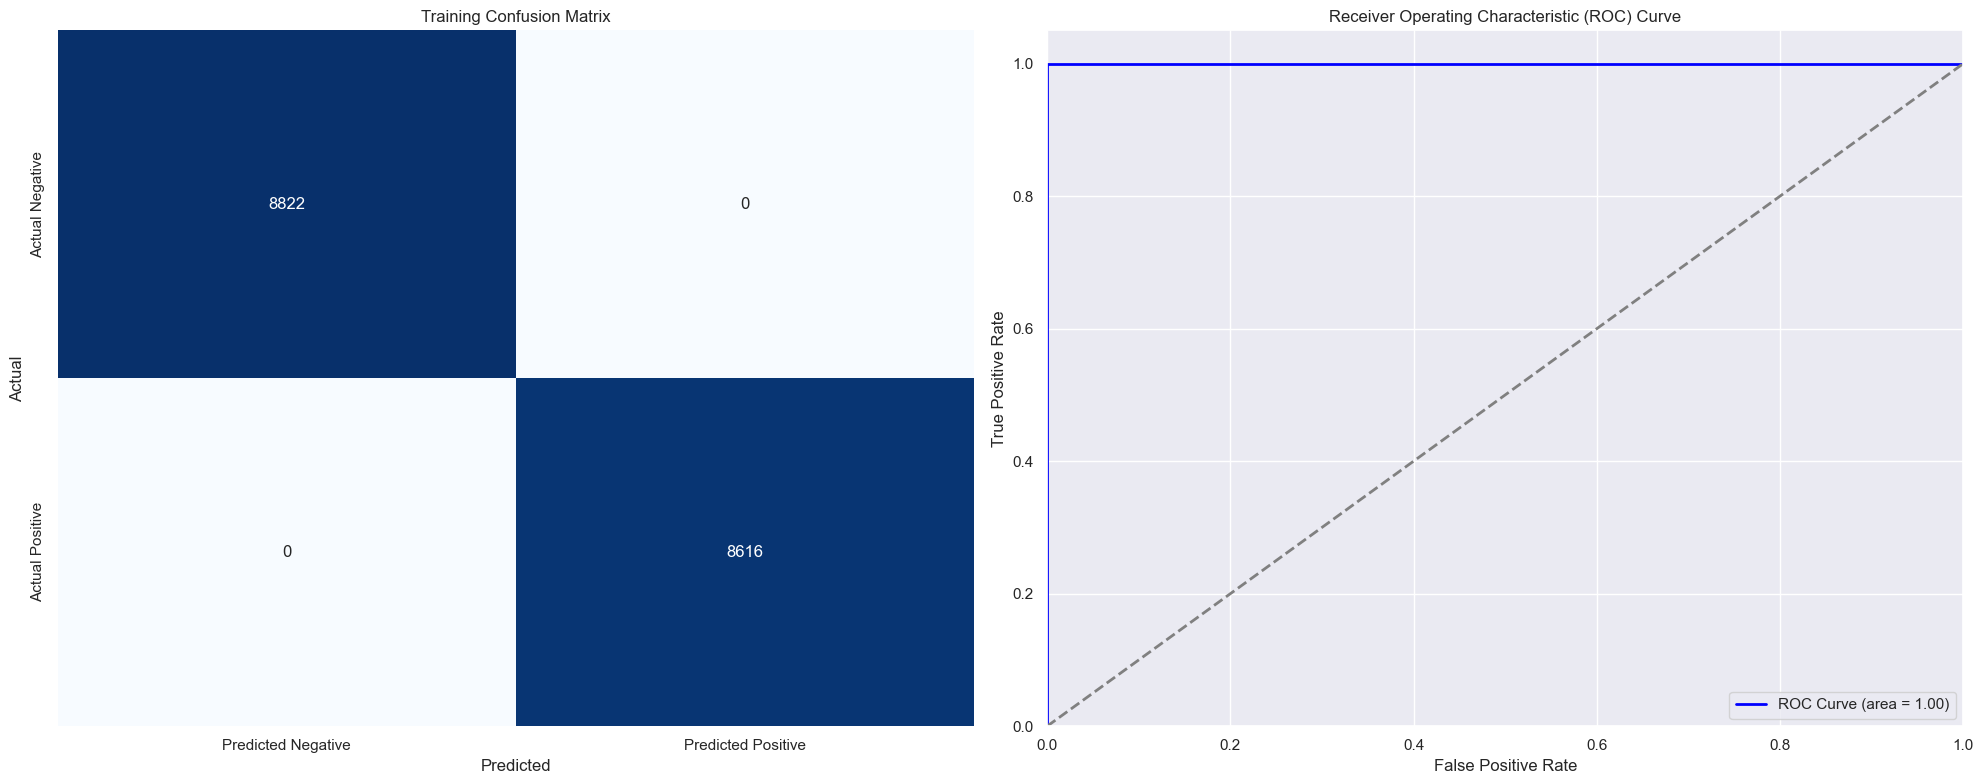

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.853768,0.724466,0.830384,0.840739,0.972577,0.980050,0.852258
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.840367,0.707057,0.814003,0.822840,0.959068,0.970535,0.838796
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846026,0.715181,0.821107,0.830066,0.963867,0.973815,0.844498
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841284,0.706128,0.814676,0.824944,0.962658,0.973255,0.839691
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.864319,0.734796,0.842561,0.856549,0.987367,0.990818,0.862807
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.844266,0.697772,0.815739,0.834322,0.981711,0.987307,0.842539
6,KNN,knn_fit,KNN - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [45]:
# initialize variables
algorithm = 'KNN'
desc = f'{algorithm} - {msg}'
model = 'knn_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.91      0.82      2206
           1       0.88      0.67      0.76      2154

    accuracy                           0.79      4360
   macro avg       0.81      0.79      0.79      4360
weighted avg       0.81      0.79      0.79      4360



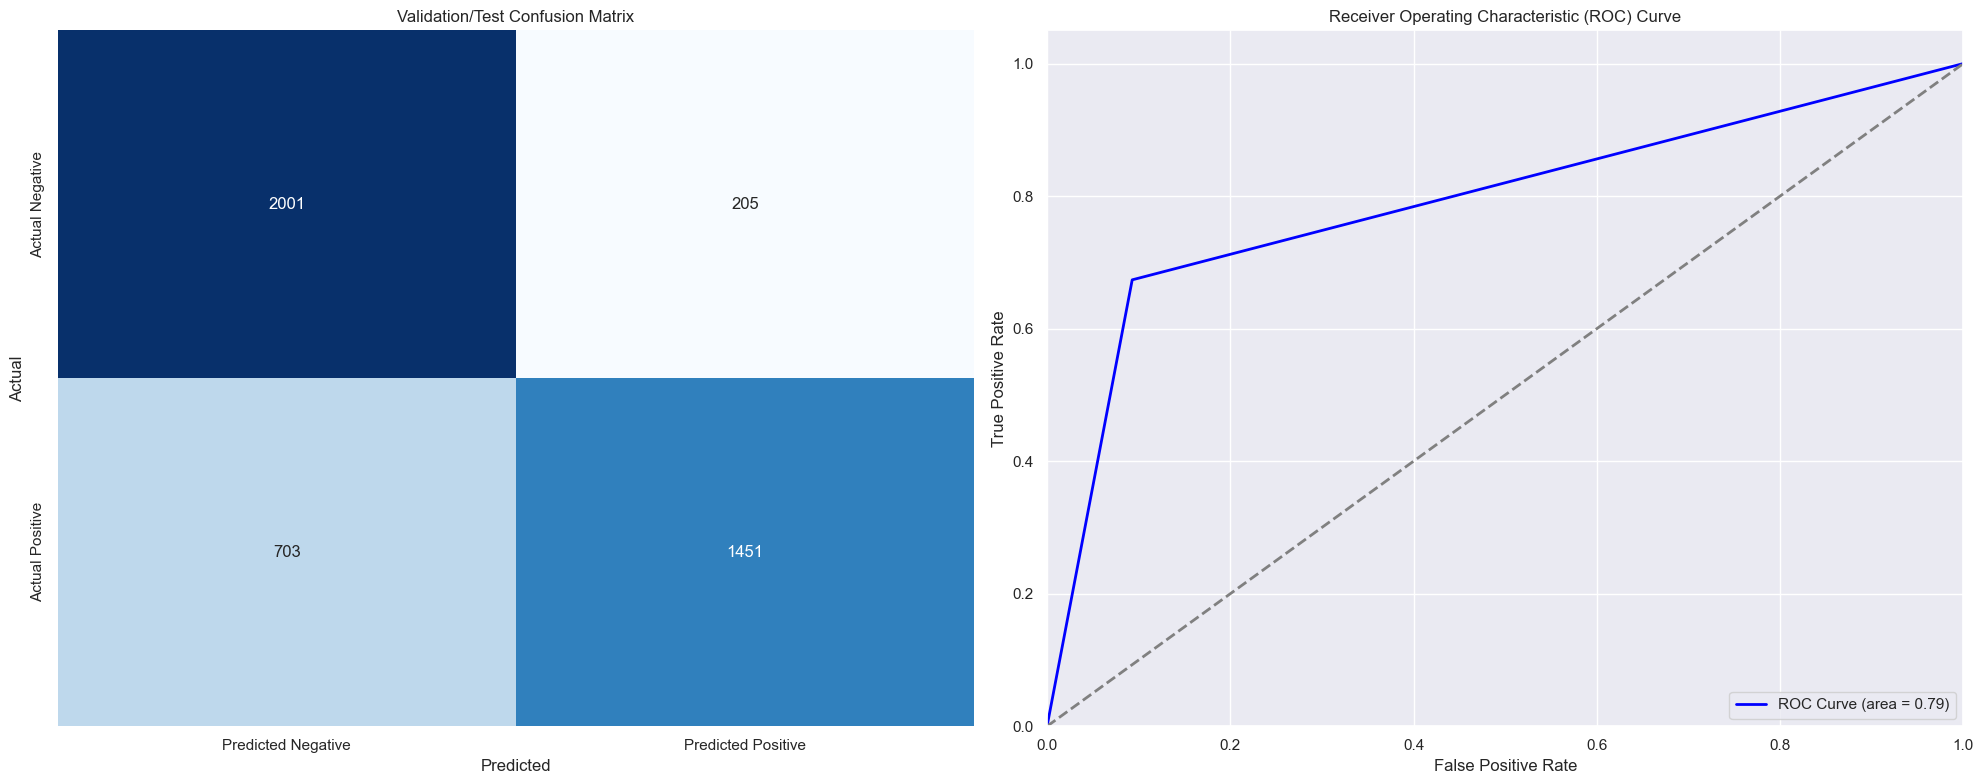

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.853768,0.724466,0.830384,0.840739,0.972577,0.980050,0.852258
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.840367,0.707057,0.814003,0.822840,0.959068,0.970535,0.838796
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846026,0.715181,0.821107,0.830066,0.963867,0.973815,0.844498
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841284,0.706128,0.814676,0.824944,0.962658,0.973255,0.839691
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.864319,0.734796,0.842561,0.856549,0.987367,0.990818,0.862807
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.844266,0.697772,0.815739,0.834322,0.981711,0.987307,0.842539
6,KNN,knn_fit,KNN - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,KNN,knn_fit,KNN - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.791743,0.673630,0.761680,0.751479,0.876208,0.907072,0.790351


In [46]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

##### Note: Clearly overfitting!

### AdaBoostClassifier

In [47]:
# import library
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# define the search space
search_space = parms.ada_search_space()

# base estimater
estimator = DecisionTreeClassifier(max_depth=1)

# create a AdaBoost model
Model = AdaBoostClassifier(estimator=estimator, algorithm='SAMME', random_state=RANDOM_STATE)

# Hyper-Parameter tuning
ada_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, youden_scorer, n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = ada_fit

Best parameters found: OrderedDict([('learning_rate', 0.9678102939165913), ('n_estimators', 368)])
Best score achieved: 0.68409508811881

Current Model Parameters:
 AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.9678102939165913, n_estimators=368,
                   random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.97      0.86      8822
           1       0.96      0.71      0.82      8616

    accuracy                           0.84     17438
   macro avg       0.87      0.84      0.84     17438
weighted avg       0.87      0.84      0.84     17438



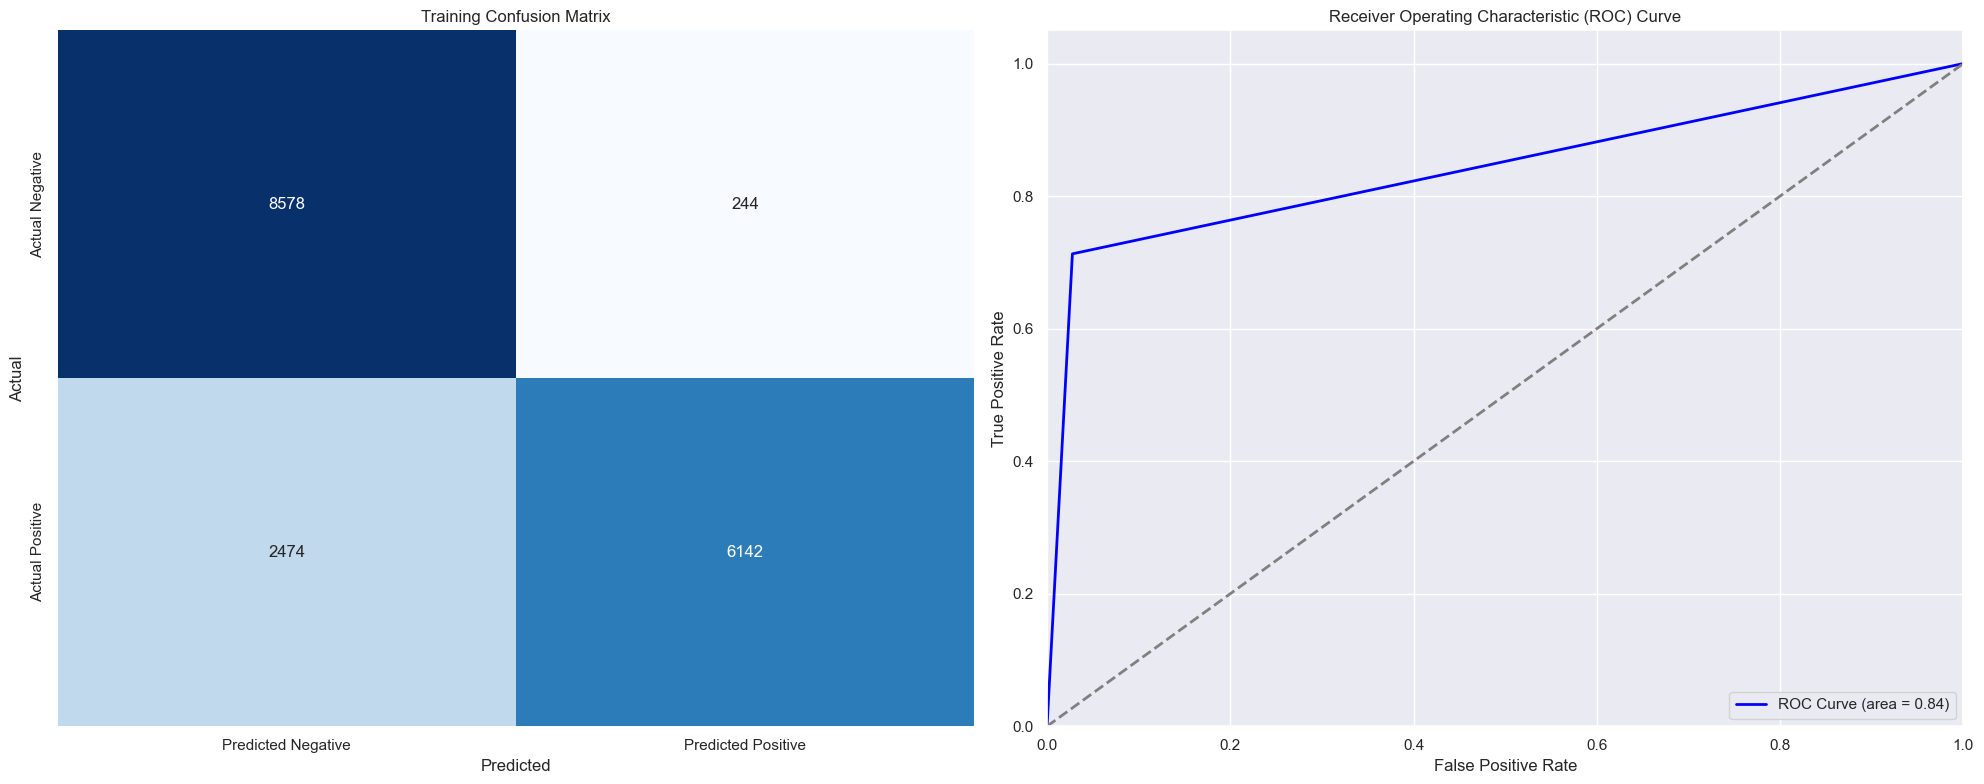

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.853768,0.724466,0.830384,0.840739,0.972577,0.980050,0.852258
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.840367,0.707057,0.814003,0.822840,0.959068,0.970535,0.838796
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846026,0.715181,0.821107,0.830066,0.963867,0.973815,0.844498
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841284,0.706128,0.814676,0.824944,0.962658,0.973255,0.839691
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.864319,0.734796,0.842561,0.856549,0.987367,0.990818,0.862807
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.844266,0.697772,0.815739,0.834322,0.981711,0.987307,0.842539
6,KNN,knn_fit,KNN - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,KNN,knn_fit,KNN - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.791743,0.673630,0.761680,0.751479,0.876208,0.907072,0.790351
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.844134,0.712860,0.818824,0.827497,0.961791,0.972342,0.842601


In [48]:
# initialize variables
algorithm = 'AdaBoost'
desc = f'{algorithm} - {msg}'
model = 'ada_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.97      0.86      2206
           1       0.96      0.70      0.81      2154

    accuracy                           0.84      4360
   macro avg       0.86      0.84      0.83      4360
weighted avg       0.86      0.84      0.83      4360



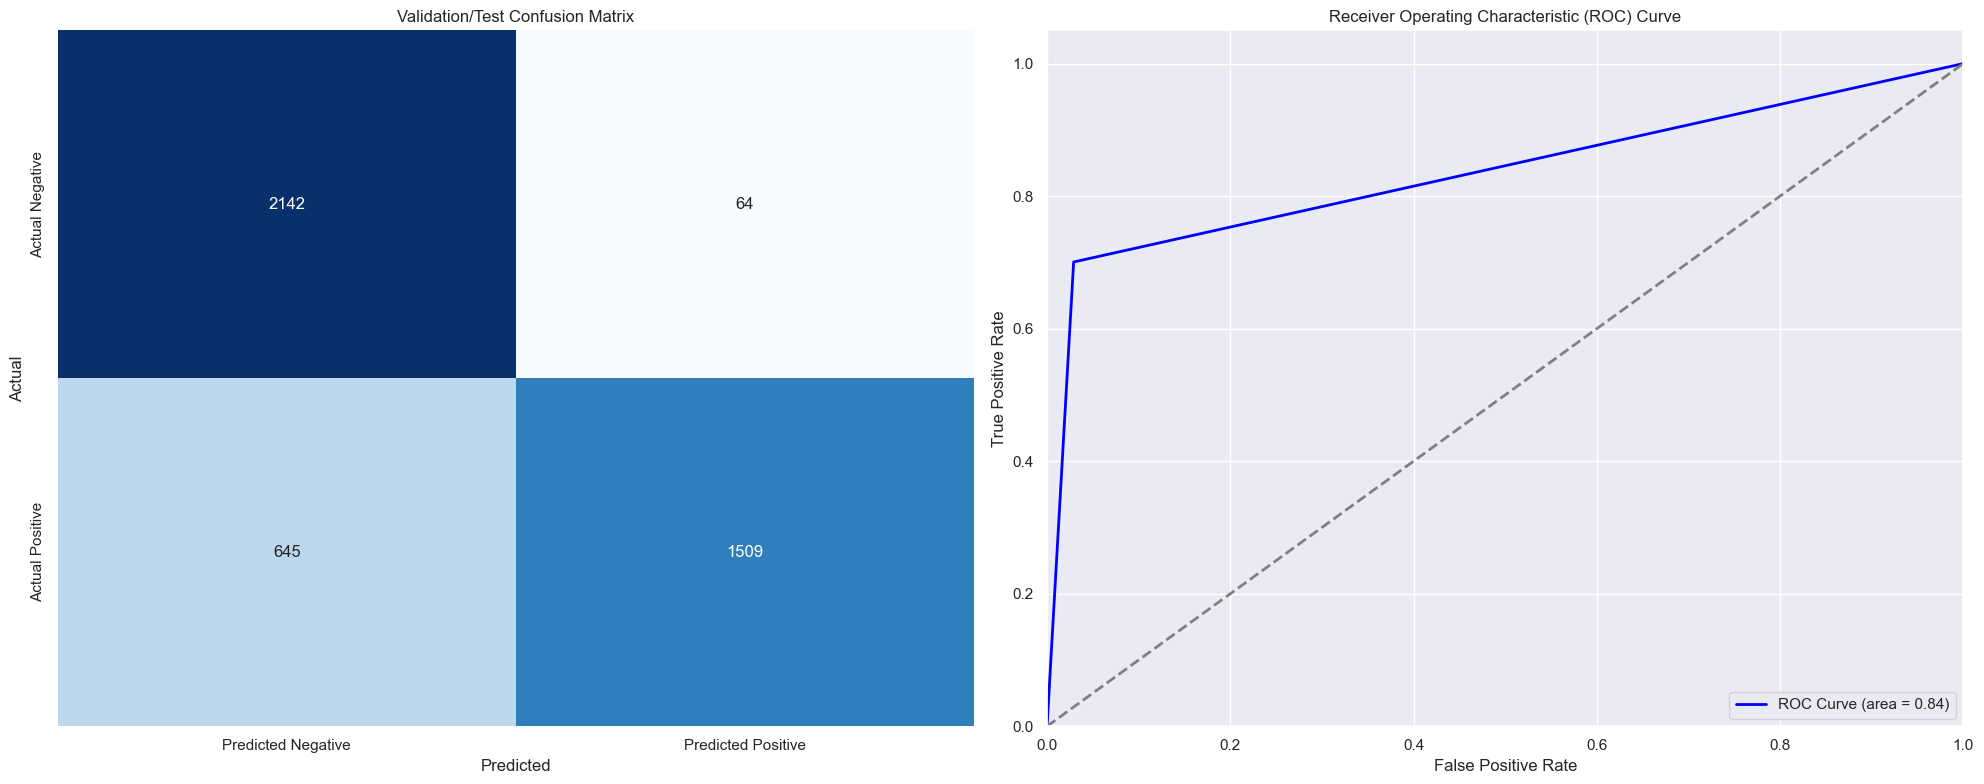

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.853768,0.724466,0.830384,0.840739,0.972577,0.980050,0.852258
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.840367,0.707057,0.814003,0.822840,0.959068,0.970535,0.838796
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846026,0.715181,0.821107,0.830066,0.963867,0.973815,0.844498
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841284,0.706128,0.814676,0.824944,0.962658,0.973255,0.839691
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.864319,0.734796,0.842561,0.856549,0.987367,0.990818,0.862807
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.844266,0.697772,0.815739,0.834322,0.981711,0.987307,0.842539
6,KNN,knn_fit,KNN - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,KNN,knn_fit,KNN - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.791743,0.673630,0.761680,0.751479,0.876208,0.907072,0.790351
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.844134,0.712860,0.818824,0.827497,0.961791,0.972342,0.842601
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.837385,0.700557,0.809767,0.819990,0.959313,0.970988,0.835773


In [49]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Feature Importance

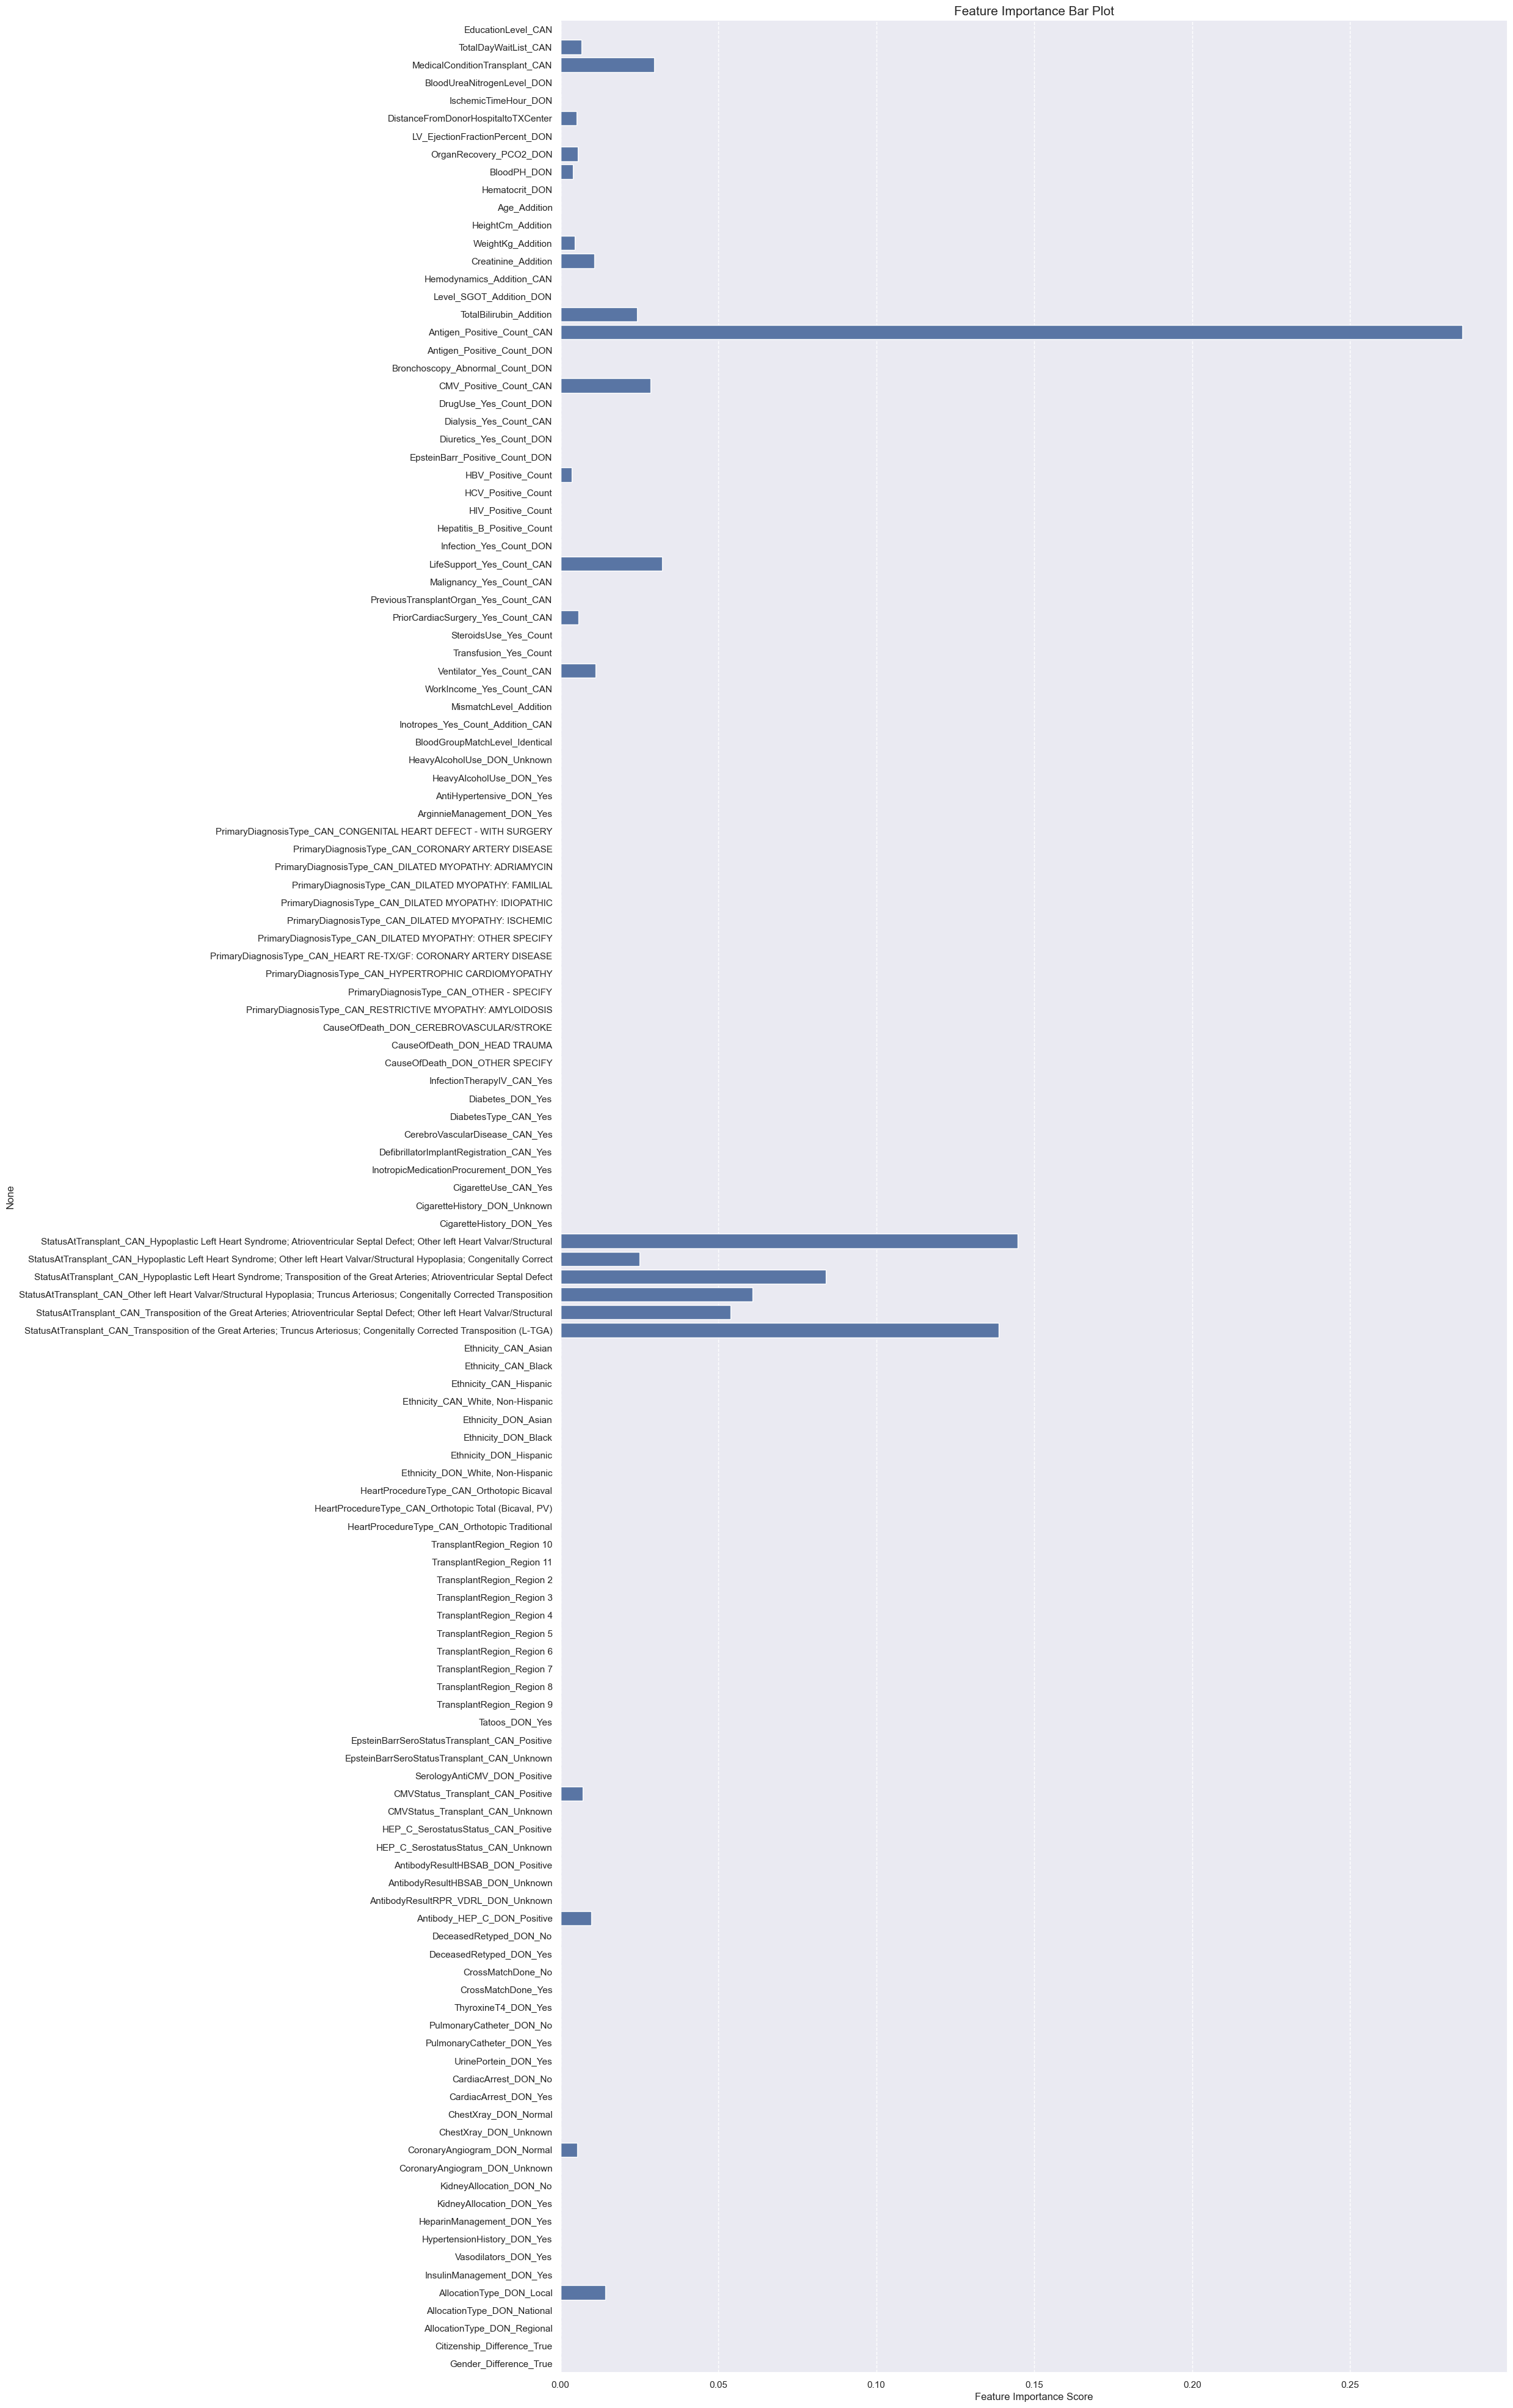

In [50]:
df_ada = umf.plot_feature_importance(Model, pd.DataFrame(X_train, columns=X_train.columns.to_list()),figsize=(20,50))

In [51]:
df_ada.sort_values(by = 'Feature Importance Score', ascending=False).head(20)

,Feature Importance Score
Antigen_Positive_Count_CAN,0.285486
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.144781
StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),0.138757
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect,0.083914
StatusAtTransplant_CAN_Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosus; Congenitally Corrected Transposition,0.060790
StatusAtTransplant_CAN_Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.053882
LifeSupport_Yes_Count_CAN,0.032192
MedicalConditionTransplant_CAN,0.029606
CMV_Positive_Count_CAN,0.028578
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct,0.024978


## Overall Model Performance

In [52]:
# display
filtered_df = df_classfication[df_classfication.DataType != 'Training']
filtered_df.sort_values(by=['Accuracy', 'ROC_AUC_Score'], ascending=False)

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.844266,0.697772,0.815739,0.834322,0.981711,0.987307,0.842539
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841284,0.706128,0.814676,0.824944,0.962658,0.973255,0.839691
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.840367,0.707057,0.814003,0.822840,0.959068,0.970535,0.838796
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.837385,0.700557,0.809767,0.819990,0.959313,0.970988,0.835773
7,KNN,knn_fit,KNN - 2011-2016: Orginal Features: Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.791743,0.673630,0.761680,0.751479,0.876208,0.907072,0.790351


## Save Model to Disk

In [53]:
import joblib

# save the model to a file
print(joblib.dump(xgb_fit, '../Models/XGBmodel_Orginal_Bayesian.joblib'))
print(joblib.dump(lrc_fit, '../Models/LRmodel_Orginal_Bayesian.joblib'))
print(joblib.dump(rfc_fit, '../Models/RFmodel_Orginal_Bayesian.joblib'))
print(joblib.dump(ada_fit, '../Models/ADAmodel_Orginal_Bayesian.joblib'))
print(joblib.dump(knn_fit, '../Models/KNNmodel_Orginal_Bayesian.joblib'))

# load the model from the file
# loaded_model = joblib.load('../Models/KNN_Threshold.joblib')

['../Models/XGBmodel_Orginal_Bayesian.joblib']
['../Models/LRmodel_Orginal_Bayesian.joblib']
['../Models/RFmodel_Orginal_Bayesian.joblib']
['../Models/ADAmodel_Orginal_Bayesian.joblib']
['../Models/KNNmodel_Orginal_Bayesian.joblib']


In [54]:
# write dataset - # X_train, y_train, X_test, y_test files
uf.write_to_file(X_train, 'X_train_GINI_Orig',path='../Data/XyData/', format='pkl')
uf.write_to_file(y_train, 'y_train_GINI_Orig',path='../Data/XyData/', format='pkl')
uf.write_to_file(X_test, 'X_test_GINI_Orig',path='../Data/XyData/', format='pkl')
uf.write_to_file(y_test, 'y_test_GINI_Orig',path='../Data/XyData/', format='pkl')

17,438 records written to ../Data/XyData/X_train_GINI_Orig.pkl
17,438 records written to ../Data/XyData/y_train_GINI_Orig.pkl
4,360 records written to ../Data/XyData/X_test_GINI_Orig.pkl
4,360 records written to ../Data/XyData/y_test_GINI_Orig.pkl
